In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
RESULTS_PATH = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step6_probe/"
    "step6_pilot_full_ithor120_diverse_qwen2_5_3b_composition_implicit_transitive_relation_ld_scene_split/"
    "step6_pilot_full_ithor120_diverse_qwen2_5_3b_composition_implicit_transitive_relation_ld_scene_split_full_results.json"
)

OUT_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/"
    "plots_step6_composition_implicit_transitive_qwen2_5_3b"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)

print("RESULTS_PATH exists:", RESULTS_PATH.exists())
print("Output directory:", OUT_DIR)

RESULTS_PATH exists: True
Output directory: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b


In [ ]:
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

print("Top-level keys:")
print(list(results.keys()))

layer_entries = results.get("results_by_layer", [])
if not layer_entries:
    raise ValueError("No results_by_layer found in the JSON file.")

sample_layer = layer_entries[0]

if "test_overall" in sample_layer:
    TEST_KEY = "test_overall"
elif "overall" in sample_layer:
    TEST_KEY = "overall"
else:
    raise KeyError(
        "Cannot find test split key. Expected either 'test_overall' or 'overall'. "
        f"Available layer keys: {list(sample_layer.keys())}"
    )

label_order = results.get("label_order")
if label_order is None:
    report = sample_layer[TEST_KEY]["classification_report"]
    label_order = [
        k for k in report.keys()
        if k not in ["accuracy", "macro avg", "weighted avg"]
    ]

layers_evaluated = sorted([int(x["layer"]) for x in layer_entries])

print("\nDetected test key:", TEST_KEY)
print("\nLabels:")
print(label_order)
print("\nLayers evaluated:")
print(layers_evaluated)
print("\nFeature key:", results.get("feature_key"))
print("Label field:", results.get("label_field"))

Top-level keys:
['experiment_id', 'experiment_name', 'experiment_description', 'script_family', 'description', 'model_name', 'model_tag', 'feature_key', 'label_field', 'probe_target', 'num_samples_loaded_after_filtering', 'num_layers', 'feature_dim', 'label_order', 'scene_split_info', 'direction_filter_info', 'final_split_summary', 'test_subset_summary', 'step6_config', 'source_pt_files', 'results_by_layer']

Detected test key: test_overall

Labels:
['above', 'below', 'left_of', 'right_of']

Layers evaluated:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]

Feature key: layer_diff_features
Label field: relation


In [ ]:
sns.set_theme(
    context="paper",
    style="whitegrid",
    font_scale=1.2
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.titlesize": 16,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def save_fig(filename):
    """
    Save current matplotlib figure as PNG and PDF.
    """
    png_path = OUT_DIR / f"{filename}.png"
    pdf_path = OUT_DIR / f"{filename}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("Saved:", png_path)
    print("Saved:", pdf_path)

In [ ]:
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    results = json.load(f)

print("Top-level keys:")
print(list(results.keys()))

layer_entries = results.get("results_by_layer", [])
if not layer_entries:
    raise ValueError("No results_by_layer found in the JSON file.")

sample_layer = layer_entries[0]

if "test_overall" in sample_layer:
    TEST_KEY = "test_overall"
elif "overall" in sample_layer:
    TEST_KEY = "overall"
else:
    raise KeyError(
        "Cannot find test split key. Expected either 'test_overall' or 'overall'. "
        f"Available layer keys: {list(sample_layer.keys())}"
    )

label_order = results.get("label_order")
if label_order is None:
    report = sample_layer[TEST_KEY]["classification_report"]
    label_order = [
        k for k in report.keys()
        if k not in ["accuracy", "macro avg", "weighted avg"]
    ]

layers_evaluated = sorted([int(x["layer"]) for x in layer_entries])

print("\nDetected test key:", TEST_KEY)
print("\nLabels:")
print(label_order)
print("\nLayers evaluated:")
print(layers_evaluated)
print("\nFeature key:", results.get("feature_key"))
print("Label field:", results.get("label_field"))

Top-level keys:
['experiment_id', 'experiment_name', 'experiment_description', 'script_family', 'description', 'model_name', 'model_tag', 'feature_key', 'label_field', 'probe_target', 'num_samples_loaded_after_filtering', 'num_layers', 'feature_dim', 'label_order', 'scene_split_info', 'direction_filter_info', 'final_split_summary', 'test_subset_summary', 'step6_config', 'source_pt_files', 'results_by_layer']

Detected test key: test_overall

Labels:
['above', 'below', 'left_of', 'right_of']

Layers evaluated:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36]

Feature key: layer_diff_features
Label field: relation


In [ ]:
def get_report_metric(subset_data, avg_name, metric_name):
    """
    Extract metric from classification_report.
    """
    report = subset_data.get("classification_report", {})
    avg_block = report.get(avg_name, {})
    return avg_block.get(metric_name, np.nan)


layer_rows = []

for layer_result in results["results_by_layer"]:
    layer = int(layer_result["layer"])

    for split_key, split_name in [("train", "train"), (TEST_KEY, "test")]:
        if split_key not in layer_result:
            continue

        subset_data = layer_result[split_key]

        layer_rows.append({
            "layer": layer,
            "split": split_name,
            "source_key": split_key,
            "num_examples": subset_data.get("num_examples", np.nan),
            "accuracy": subset_data.get("accuracy", np.nan),
            "macro_precision": get_report_metric(subset_data, "macro avg", "precision"),
            "macro_recall": get_report_metric(subset_data, "macro avg", "recall"),
            "macro_f1": subset_data.get(
                "macro_f1",
                get_report_metric(subset_data, "macro avg", "f1-score")
            ),
            "weighted_precision": get_report_metric(subset_data, "weighted avg", "precision"),
            "weighted_recall": get_report_metric(subset_data, "weighted avg", "recall"),
            "weighted_f1": get_report_metric(subset_data, "weighted avg", "f1-score"),
        })

df_layers = pd.DataFrame(layer_rows).sort_values(["split", "layer"]).reset_index(drop=True)

print("df_layers:")
print(df_layers.head())
print("\nShape:", df_layers.shape)

df_layers:
   layer split    source_key  num_examples  accuracy  macro_precision  \
0      0  test  test_overall           373  0.383378         0.264962   
1      1  test  test_overall           373  0.793566         0.607151   
2      2  test  test_overall           373  0.852547         0.688196   
3      3  test  test_overall           373  0.849866         0.709487   
4      4  test  test_overall           373  0.820375         0.561166   

   macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1  
0      0.359825  0.249607            0.477379         0.383378     0.418868  
1      0.772789  0.661830            0.807028         0.793566     0.797863  
2      0.762894  0.718941            0.857169         0.852547     0.854181  
3      0.761543  0.729765            0.853930         0.849866     0.851162  
4      0.666116  0.594845            0.837147         0.820375     0.826143  

Shape: (74, 11)


In [ ]:
METRIC_NAME_MAP = {
    "accuracy": "Accuracy",
    "macro_precision": "Macro precision",
    "macro_recall": "Macro recall",
    "macro_f1": "Macro F1",
    "weighted_precision": "Weighted precision",
    "weighted_recall": "Weighted recall",
    "weighted_f1": "Weighted F1",
}


def require_metric_column(df, metric_col):
    """
    Check that metric_col is a real numeric column and has a display name.
    """
    if metric_col not in df.columns:
        raise ValueError(
            f"Metric column '{metric_col}' does not exist in dataframe. "
            f"Available columns: {list(df.columns)}"
        )

    if metric_col not in METRIC_NAME_MAP:
        raise ValueError(
            f"Metric column '{metric_col}' exists, but it is not registered in METRIC_NAME_MAP."
        )

    if not pd.api.types.is_numeric_dtype(df[metric_col]):
        raise TypeError(f"Metric column '{metric_col}' is not numeric.")

    if df[metric_col].isna().all():
        raise ValueError(f"Metric column '{metric_col}' contains only NaN.")

    return METRIC_NAME_MAP[metric_col]

In [ ]:
df_test = df_layers[df_layers["split"] == "test"].copy()
df_test = df_test.sort_values("layer").reset_index(drop=True)

df_train_test = df_layers[
    df_layers["split"].isin(["train", "test"])
].copy()

df_train_test = df_train_test.sort_values(["split", "layer"]).reset_index(drop=True)

print("df_test:")
print(df_test.head())

print("\ndf_train_test:")
print(df_train_test.head())

print("\ndf_train_test shape:", df_train_test.shape)

df_test:
   layer split    source_key  num_examples  accuracy  macro_precision  \
0      0  test  test_overall           373  0.383378         0.264962   
1      1  test  test_overall           373  0.793566         0.607151   
2      2  test  test_overall           373  0.852547         0.688196   
3      3  test  test_overall           373  0.849866         0.709487   
4      4  test  test_overall           373  0.820375         0.561166   

   macro_recall  macro_f1  weighted_precision  weighted_recall  weighted_f1  
0      0.359825  0.249607            0.477379         0.383378     0.418868  
1      0.772789  0.661830            0.807028         0.793566     0.797863  
2      0.762894  0.718941            0.857169         0.852547     0.854181  
3      0.761543  0.729765            0.853930         0.849866     0.851162  
4      0.666116  0.594845            0.837147         0.820375     0.826143  

df_train_test:
   layer split    source_key  num_examples  accuracy  macro_precisio

In [ ]:
def plot_test_metric_with_best_and_second_worst(metric_col, save_name):
    metric_label = require_metric_column(df_test, metric_col)

    plt.figure(figsize=(22, 7))

    sns.lineplot(
        data=df_test,
        x="layer",
        y=metric_col,
        marker="o",
        linewidth=2.0,
        color=sns.color_palette("muted")[0]
    )

    best_row = df_test.loc[df_test[metric_col].idxmax()]
    best_metric_layer = int(best_row["layer"])
    best_score = float(best_row[metric_col])

    sorted_df = df_test.sort_values(metric_col, ascending=True).reset_index(drop=True)
    second_worst_row = sorted_df.iloc[1] if len(sorted_df) > 1 else sorted_df.iloc[0]
    second_worst_layer = int(second_worst_row["layer"])
    second_worst_score = float(second_worst_row[metric_col])

    plt.scatter(
        [best_metric_layer],
        [best_score],
        s=90,
        zorder=5,
        label=f"Best L{best_metric_layer}: {best_score:.3f}",
        color="green",
        alpha=0.8
    )

    plt.scatter(
        [second_worst_layer],
        [second_worst_score],
        s=90,
        zorder=5,
        label=f"Second worst L{second_worst_layer}: {second_worst_score:.3f}",
        color="red",
        alpha=0.8
    )

    plt.axvline(
        best_metric_layer,
        linestyle="--",
        linewidth=1.3,
        alpha=0.8,
        color="green"
    )

    plt.axvline(
        second_worst_layer,
        linestyle="--",
        linewidth=1.3,
        alpha=0.8,
        color="red"
    )

    # Best 点的方框注释（无箭头）
    plt.annotate(
        f"Best\nL{best_metric_layer}: {best_score:.3f}",
        xy=(best_metric_layer, best_score),
        xytext=(12, 12),              # 相对点的位置偏移
        textcoords="offset points",
        fontsize=11,
        color="black",
        ha="left",
        va="bottom",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="gray",
            alpha=0.95
        )
    )

    # Second worst 点的方框注释（无箭头）
    plt.annotate(
        f"Second worst\nL{second_worst_layer}: {second_worst_score:.3f}",
        xy=(second_worst_layer, second_worst_score),
        xytext=(12, -35),             # 放到点的右下方，避免重叠
        textcoords="offset points",
        fontsize=11,
        color="black",
        ha="left",
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="gray",
            alpha=0.95
        )
    )

    plt.title(f"Test {metric_label} across layers", fontsize=30)
    plt.xlabel("Layer", fontsize=22)
    plt.ylabel(metric_label, fontsize=22)

    plt.ylim(0, 1.05)
    plt.yticks(np.arange(0, 1.01, 0.1), fontsize=16)
    plt.xticks(sorted(df_test["layer"].unique()), fontsize=16)

    plt.legend(
        title=None,
        frameon=True,
        fontsize=16,
        loc="lower right"
        )
    plt.tight_layout()

    save_fig(save_name)
    plt.show()

In [ ]:
BEST_LAYER_METRIC_COL = "macro_f1"
BEST_LAYER_METRIC_LABEL = require_metric_column(df_test, BEST_LAYER_METRIC_COL)

best_row = df_test.sort_values(BEST_LAYER_METRIC_COL, ascending=False).iloc[0]
best_layer = int(best_row["layer"])

print(f"Best layer based on test {BEST_LAYER_METRIC_LABEL}:", best_layer)
print(best_row)

Best layer based on test Macro F1: 19
layer                           19
split                         test
source_key            test_overall
num_examples                   373
accuracy                  0.831099
macro_precision           0.832633
macro_recall              0.751738
macro_f1                  0.783797
weighted_precision        0.832188
weighted_recall           0.831099
weighted_f1               0.831002
Name: 19, dtype: object


Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_all_metrics.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_all_metrics.pdf


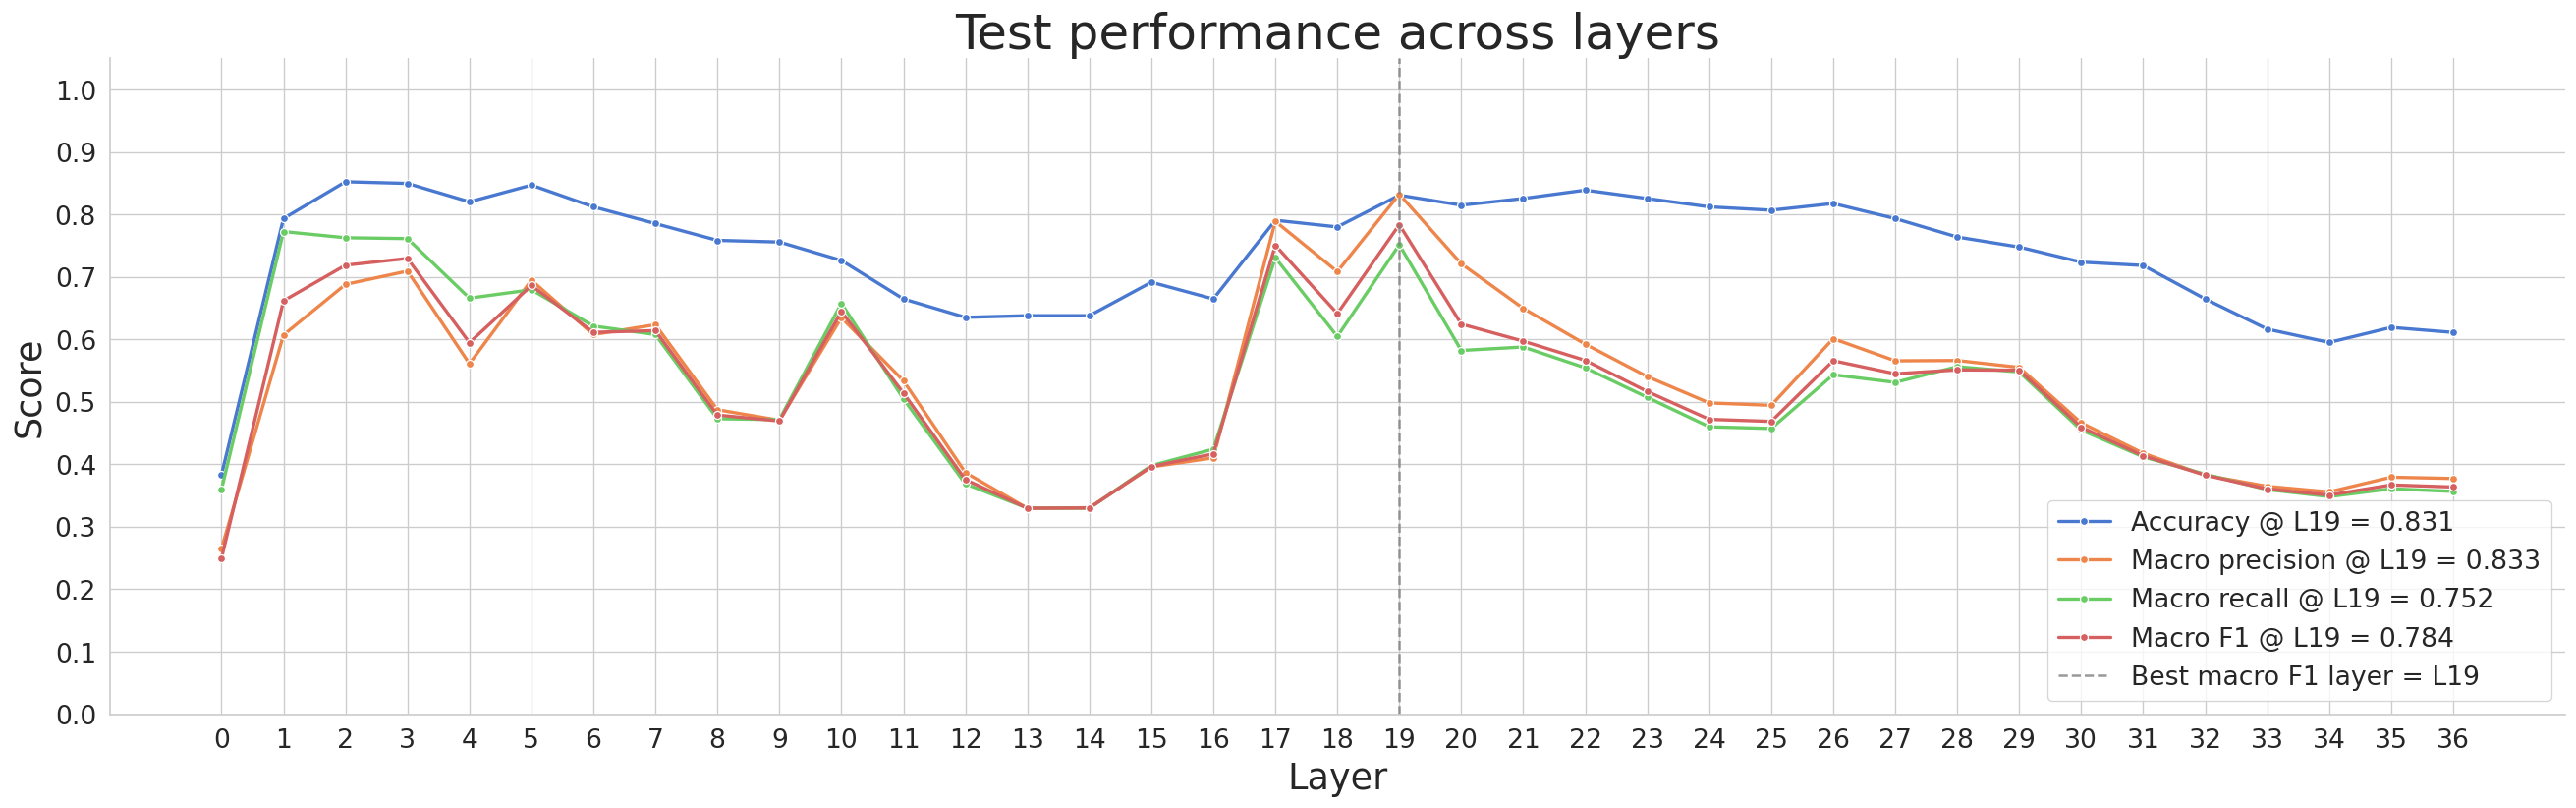

In [ ]:
metric_cols = ["accuracy", "macro_precision", "macro_recall", "macro_f1"]

for metric_col in metric_cols:
    require_metric_column(df_test, metric_col)

plot_df = df_test.melt(
    id_vars=["layer"],
    value_vars=metric_cols,
    var_name="metric_col",
    value_name="score"
)

plot_df["metric"] = plot_df["metric_col"].map(METRIC_NAME_MAP)

best_metrics = df_test[df_test["layer"] == best_layer].iloc[0]

best_metric_values = {
    METRIC_NAME_MAP[metric_col]: best_metrics[metric_col]
    for metric_col in metric_cols
}

plot_df["legend_label"] = plot_df["metric"].apply(
    lambda m: f"{m} @ L{best_layer} = {best_metric_values[m]:.3f}"
)

plt.figure(figsize=(22, 7))

sns.lineplot(
    data=plot_df,
    x="layer",
    y="score",
    hue="legend_label",
    marker="o",
    linewidth=2.0,
    palette="muted"
)

plt.axvline(
    best_layer,
    linestyle="--",
    linewidth=1.5,
    alpha=0.8,
    label=f"Best macro F1 layer = L{best_layer}",
    color="grey"
)

plt.title("Test performance across layers", fontsize=30)
plt.xlabel("Layer", fontsize=22)
plt.ylabel("Score",fontsize=22)
plt.ylim(0, 1.05)
plt.yticks(np.arange(0, 1.01, 0.1), fontsize=16)
plt.xticks(sorted(df_test["layer"].unique()), fontsize=16)
plt.legend(
    title=None,
    frameon=True,
    loc="lower right",
    fontsize=16
    )
plt.tight_layout()

save_fig("test_layerwise_all_metrics")
plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_accuracy_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_accuracy_with_best_and_second_worst_value.pdf


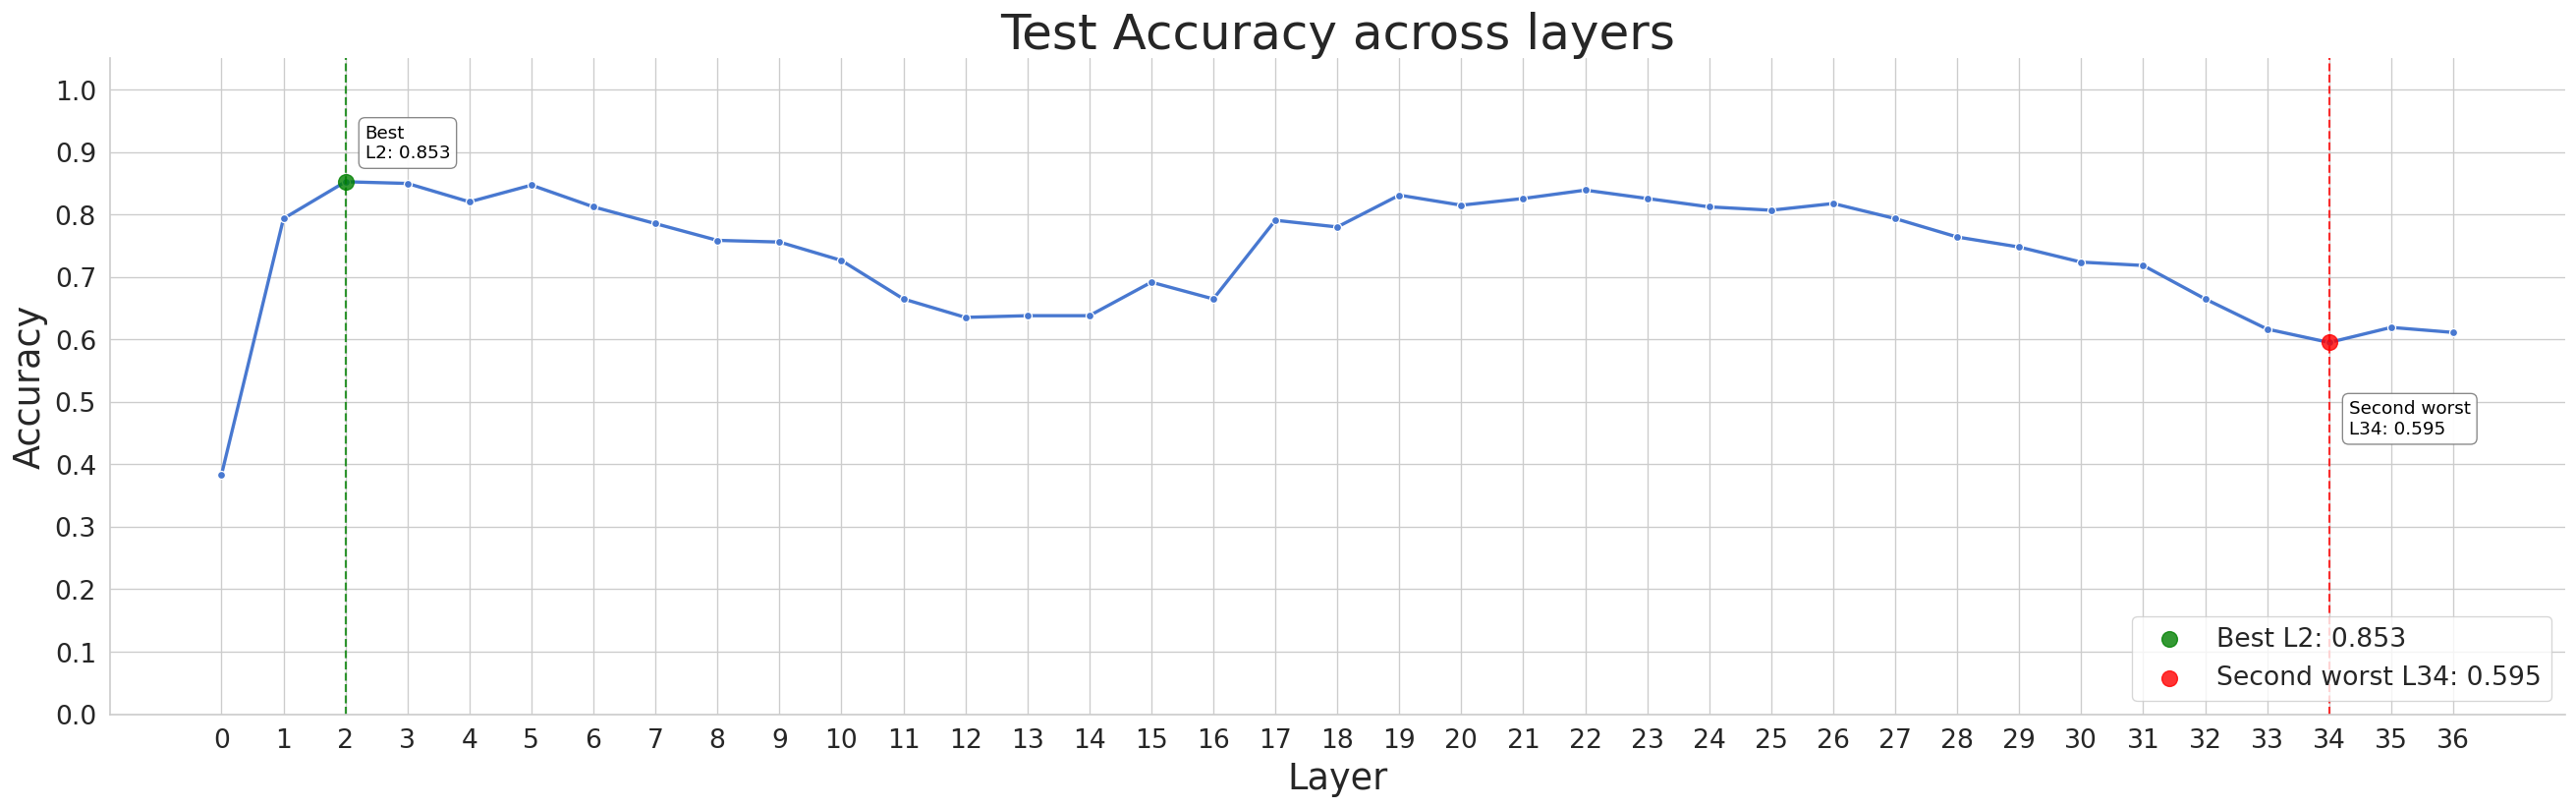

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="accuracy",
    save_name="test_layerwise_accuracy_with_best_and_second_worst_value"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_macro_precision_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_macro_precision_with_best_and_second_worst_value.pdf


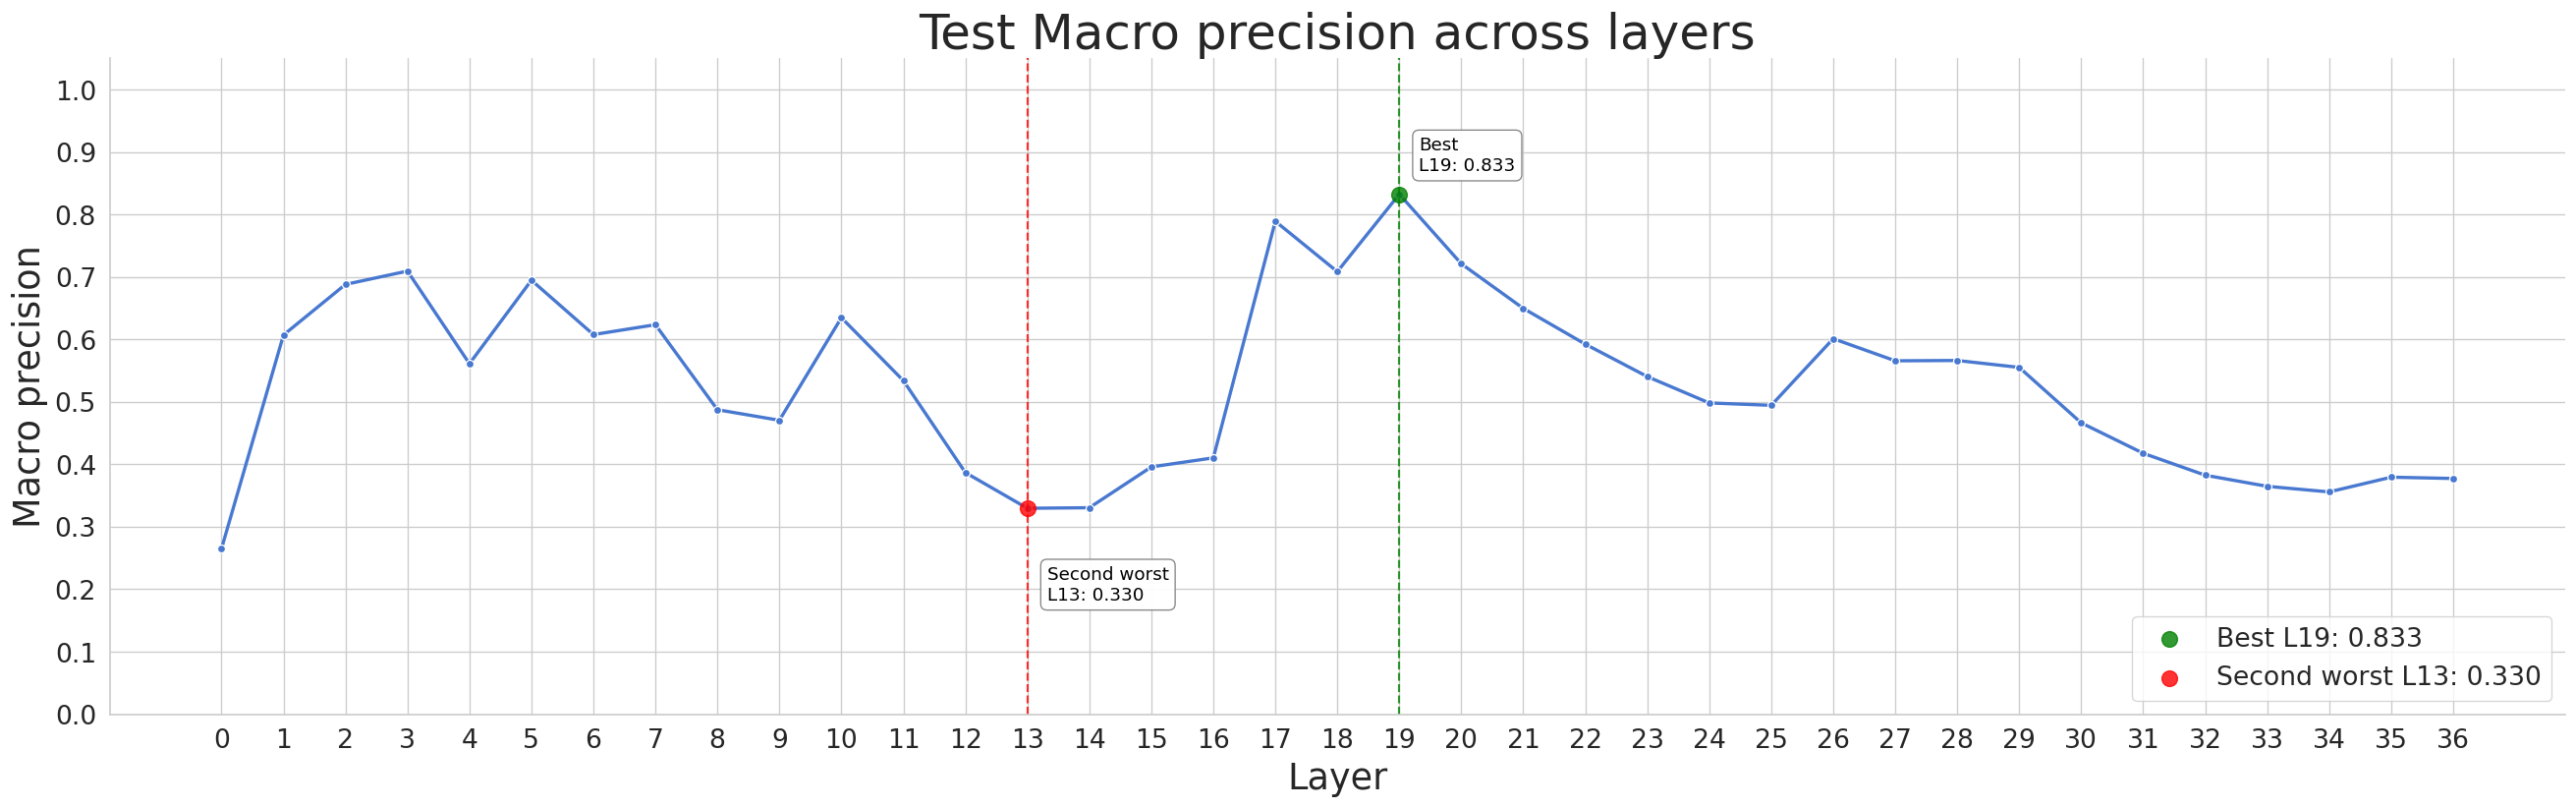

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="macro_precision",
    save_name="test_layerwise_macro_precision_with_best_and_second_worst_value"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_macro_recall_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_macro_recall_with_best_and_second_worst_value.pdf


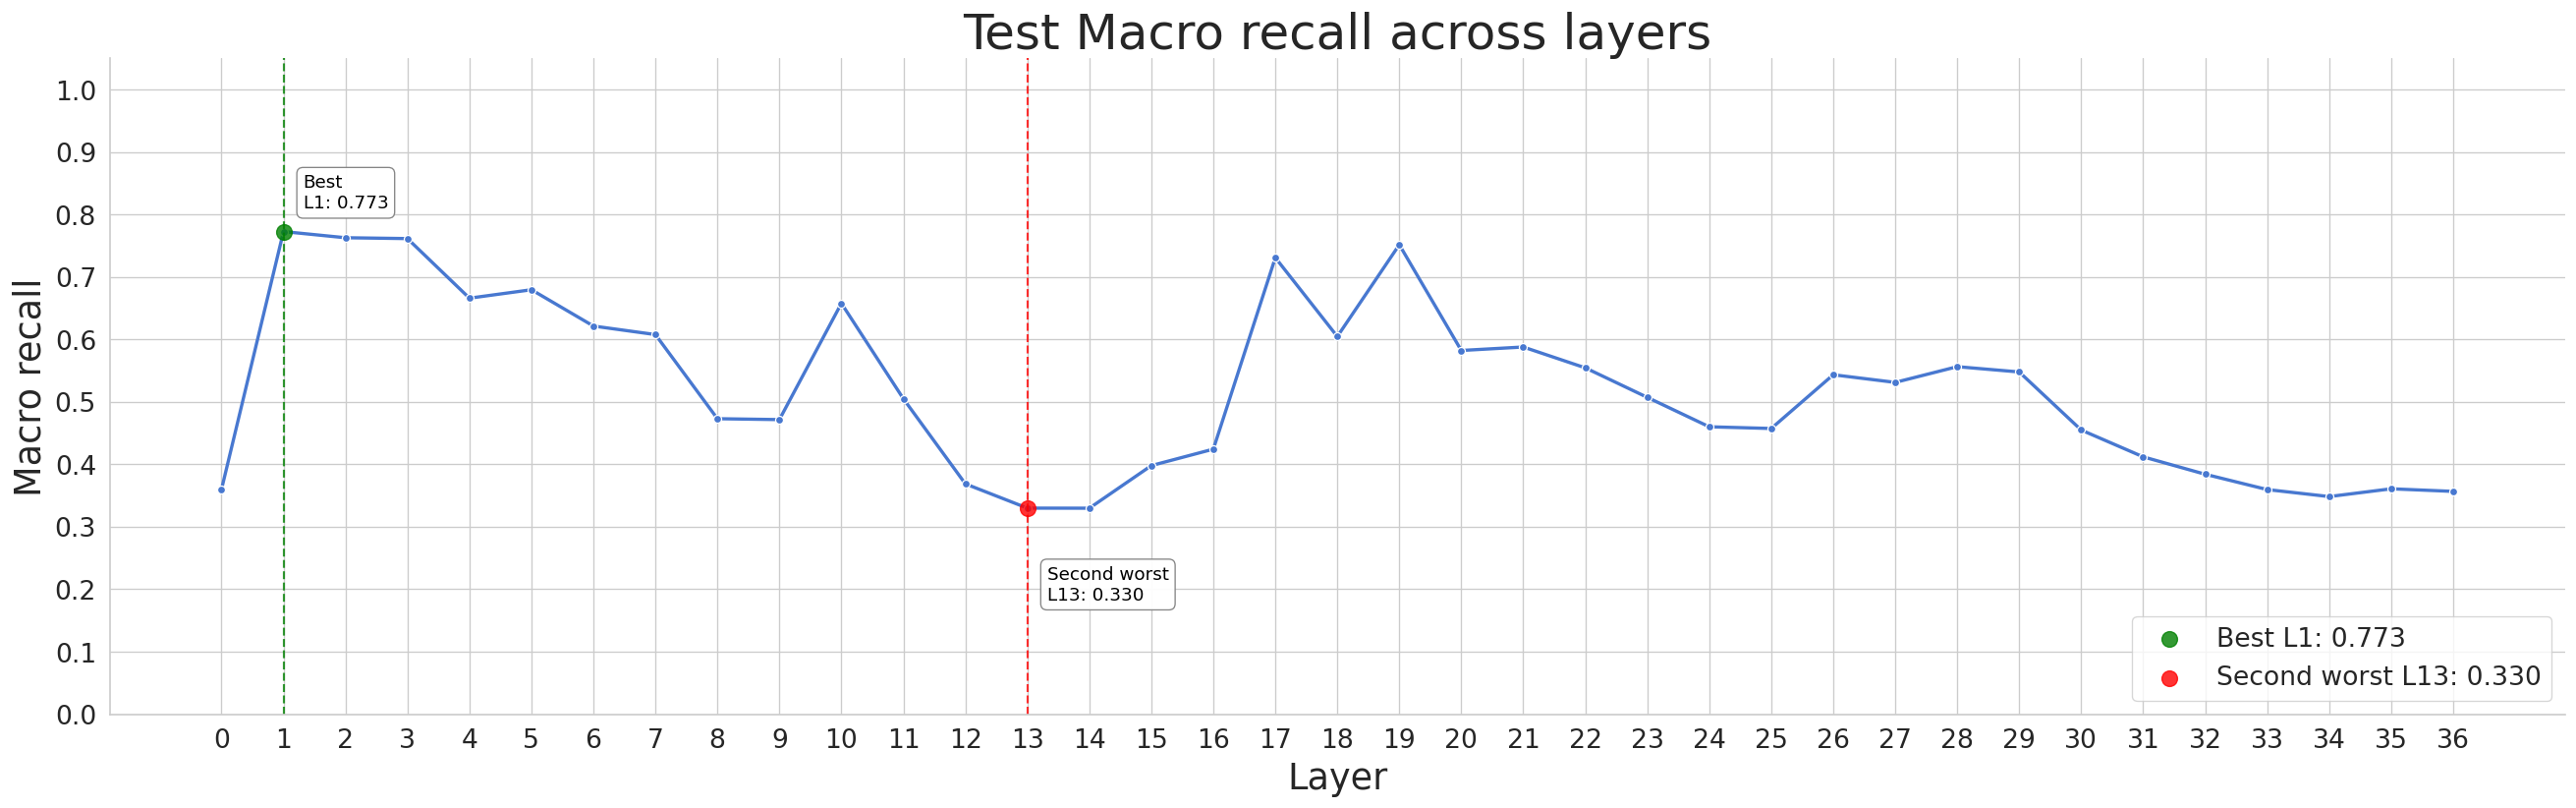

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="macro_recall",
    save_name="test_layerwise_macro_recall_with_best_and_second_worst_value"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_macro_f1_with_best_and_second_worst_value.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_layerwise_macro_f1_with_best_and_second_worst_value.pdf


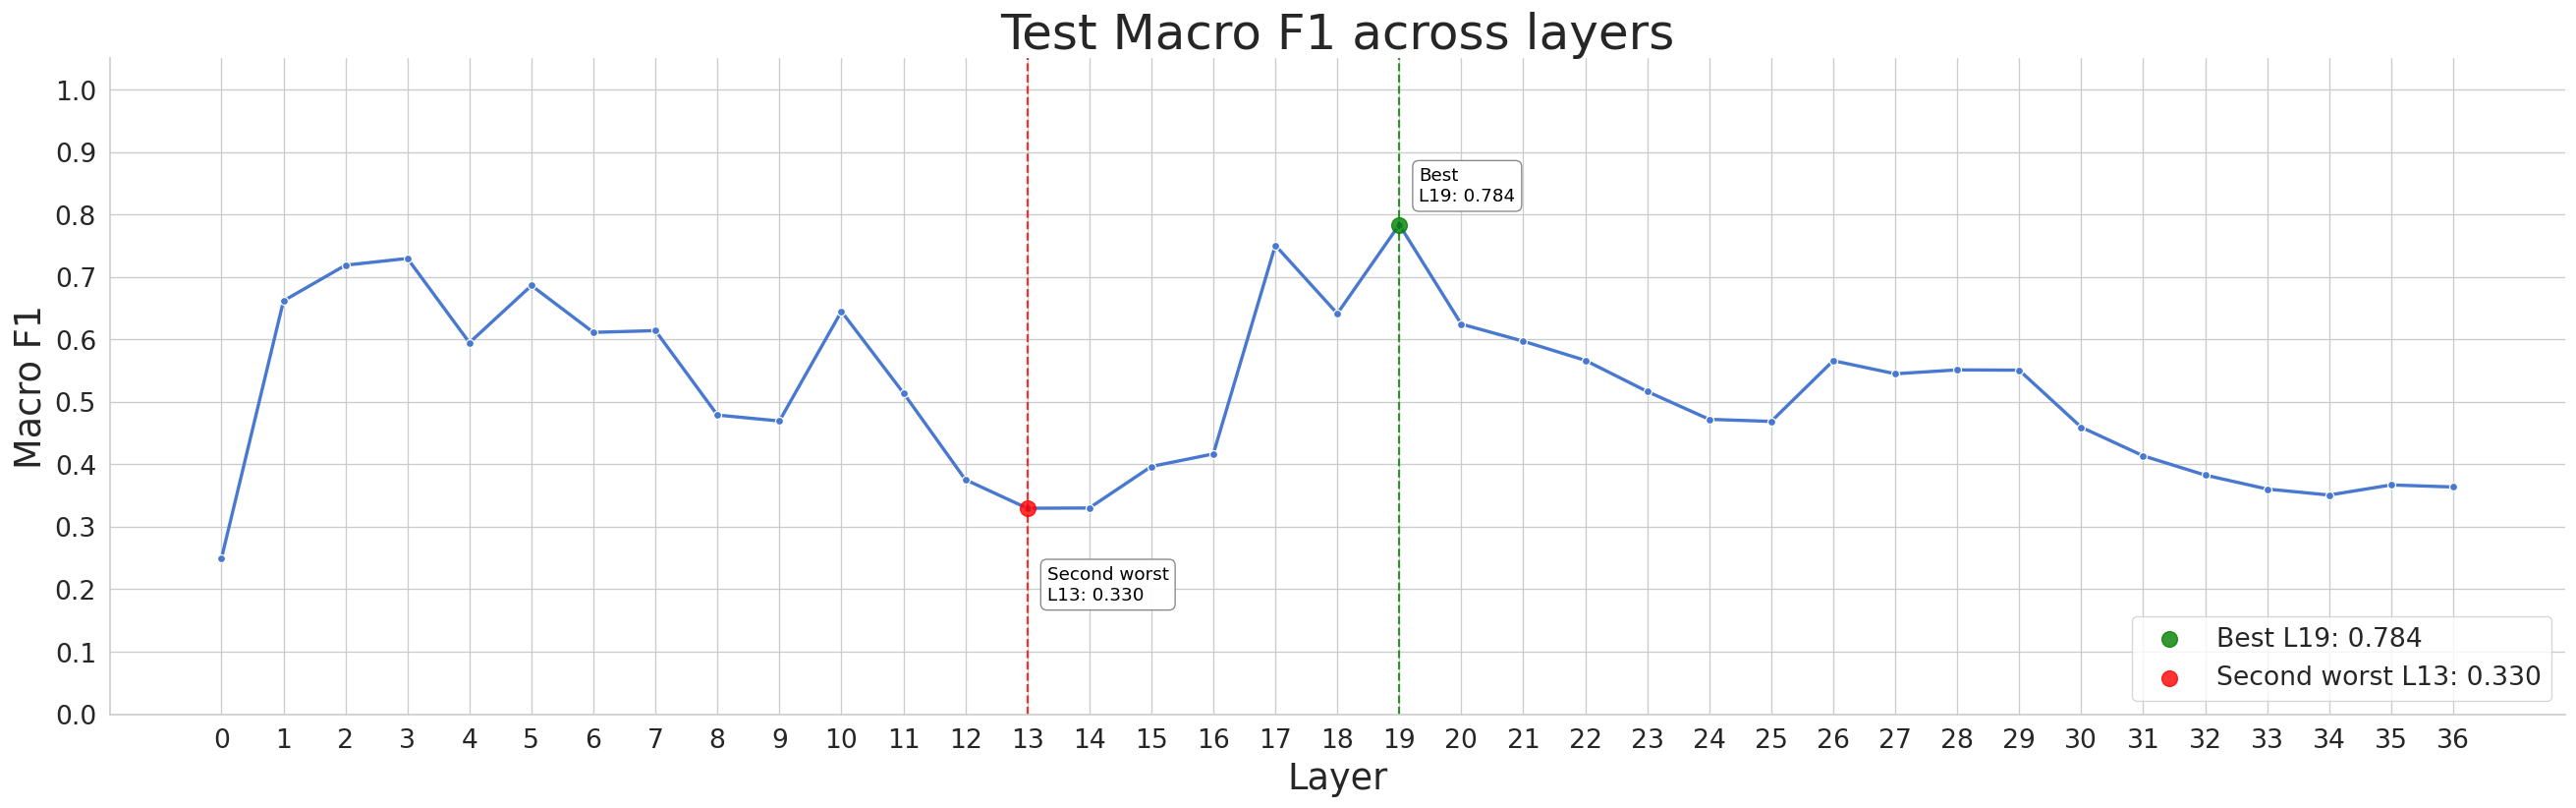

In [ ]:
plot_test_metric_with_best_and_second_worst(
    metric_col="macro_f1",
    save_name="test_layerwise_macro_f1_with_best_and_second_worst_value"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_train_vs_test_metrics.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_train_vs_test_metrics.pdf


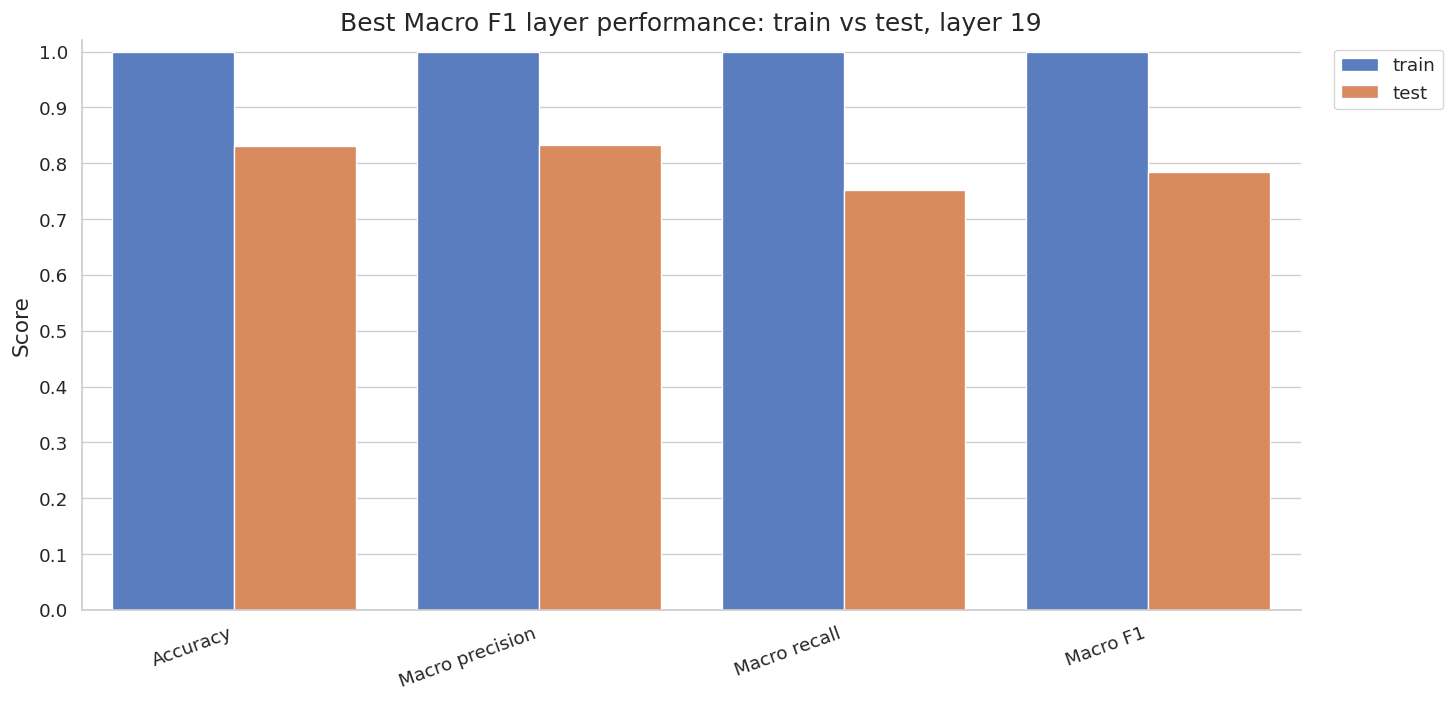

In [ ]:
best_compare = df_train_test[
    (df_train_test["layer"] == best_layer) &
    (df_train_test["split"].isin(["train", "test"]))
].copy()

best_compare_long = best_compare.melt(
    id_vars=["layer", "split"],
    value_vars=["accuracy", "macro_precision", "macro_recall", "macro_f1"],
    var_name="metric_col",
    value_name="score"
)

best_compare_long["metric"] = best_compare_long["metric_col"].map(METRIC_NAME_MAP)

plt.figure(figsize=(15, 6))

sns.barplot(
    data=best_compare_long,
    x="metric",
    y="score",
    hue="split",
    palette="muted",
    hue_order=["train", "test"],
)

plt.title(f"Best {BEST_LAYER_METRIC_LABEL} layer performance: train vs test, layer {best_layer}")
plt.xlabel("")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.legend(
    title=None,
    frameon=True,
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)
plt.xticks(rotation=20, ha="right")
plt.tight_layout(rect=[0, 0, 0.82, 1])

save_fig(f"best_macro_f1_layer_{best_layer}_train_vs_test_metrics")
plt.show()

In [ ]:
def plot_train_test_metric_with_best(
    metric_col,
    save_name,
    annotation_offsets=None,
    legend_loc="lower right"
):
    """
    Plot train/test layer-wise metric curves and mark the best layer
    for each split.

    Parameters
    ----------
    metric_col : str
        Metric column to plot, e.g. "accuracy", "macro_f1", "weighted_f1".

    save_name : str
        Output filename prefix used by save_fig(save_name).

    annotation_offsets : dict or None
        Controls annotation box positions separately for train/test.

        Example:
        {
            "train": {"xytext": (14, -20), "ha": "left", "va": "top"},
            "test":  {"xytext": (14, 18),  "ha": "left", "va": "bottom"},
        }

        xytext is measured in offset points relative to the marked point.

    legend_loc : str
        Legend position, e.g. "lower right", "upper right", "lower left".
    """

    metric_label = require_metric_column(df_train_test, metric_col)

    plt.figure(figsize=(22, 7))

    ax = sns.lineplot(
        data=df_train_test,
        x="layer",
        y=metric_col,
        hue="split",
        marker="o",
        linewidth=2.0,
        palette="muted"
    )

    # ------------------------------------------------------------
    # 1. Get train/test line colors from seaborn legend handles
    # ------------------------------------------------------------
    handles, labels = ax.get_legend_handles_labels()
    split_color_map = {}

    for handle, label in zip(handles, labels):
        if label in ["train", "test"]:
            try:
                split_color_map[label] = handle.get_color()
            except AttributeError:
                split_color_map[label] = None

    fallback_colors = {
        "train": sns.color_palette("muted")[0],
        "test": sns.color_palette("muted")[1],
    }

    for split_name in ["train", "test"]:
        if split_name not in split_color_map or split_color_map[split_name] is None:
            split_color_map[split_name] = fallback_colors[split_name]

    # ------------------------------------------------------------
    # 2. Default annotation positions
    #    These are used only if no custom positions are passed.
    # ------------------------------------------------------------
    default_annotation_offsets = {
        "train": {
            "xytext": (14, -20),   # right and below the point
            "ha": "left",
            "va": "top"
        },
        "test": {
            "xytext": (14, -60),   # right and further below the point
            "ha": "left",
            "va": "top"
        }
    }

    if annotation_offsets is None:
        annotation_offsets = default_annotation_offsets
    else:
        # Merge user-provided settings with defaults.
        # This allows you to specify only train or only test if needed.
        merged_offsets = {}

        for split_name in ["train", "test"]:
            merged_offsets[split_name] = default_annotation_offsets[split_name].copy()

            if split_name in annotation_offsets:
                merged_offsets[split_name].update(annotation_offsets[split_name])

        annotation_offsets = merged_offsets

    # ------------------------------------------------------------
    # 3. Mark best layer for train and test separately
    # ------------------------------------------------------------
    for split_name in ["train", "test"]:
        split_df = df_train_test[df_train_test["split"] == split_name].copy()

        if split_df.empty:
            raise ValueError(f"No rows found for split='{split_name}'.")

        best_row = split_df.loc[split_df[metric_col].idxmax()]
        best_layer_for_split = int(best_row["layer"])
        best_score = float(best_row[metric_col])
        split_color = split_color_map[split_name]

        plt.scatter(
            [best_layer_for_split],
            [best_score],
            s=90,
            zorder=5,
            color=split_color,
            alpha=0.9,
            label=f"{split_name} best L{best_layer_for_split}: {best_score:.3f}"
        )

        plt.axvline(
            best_layer_for_split,
            linestyle="--",
            linewidth=1.3,
            alpha=0.8,
            color=split_color
        )

        cfg = annotation_offsets[split_name]

        plt.annotate(
            f"{split_name} best\nL{best_layer_for_split}: {best_score:.3f}",
            xy=(best_layer_for_split, best_score),
            xytext=cfg["xytext"],
            textcoords="offset points",
            fontsize=16,
            color="black",
            ha=cfg["ha"],
            va=cfg["va"],
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor="gray",
                alpha=0.95
            ),
            zorder=10,
            clip_on=False
        )

    # ------------------------------------------------------------
    # 4. Figure styling
    # ------------------------------------------------------------
    plt.title(f"Train vs test {metric_label} across layers", fontsize=30)
    plt.xlabel("Layer", fontsize=16)
    plt.ylabel(metric_label, fontsize=16)

    plt.ylim(0, 1.10)
    plt.yticks(np.arange(0, 1.01, 0.1), fontsize=11)
    plt.xticks(sorted(df_train_test["layer"].unique()), fontsize=11)

    plt.legend(
        title=None,
        frameon=True,
        fontsize=16,
        loc=legend_loc
    )

    plt.tight_layout()

    save_fig(save_name)
    plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_accuracy_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_accuracy_with_best.pdf


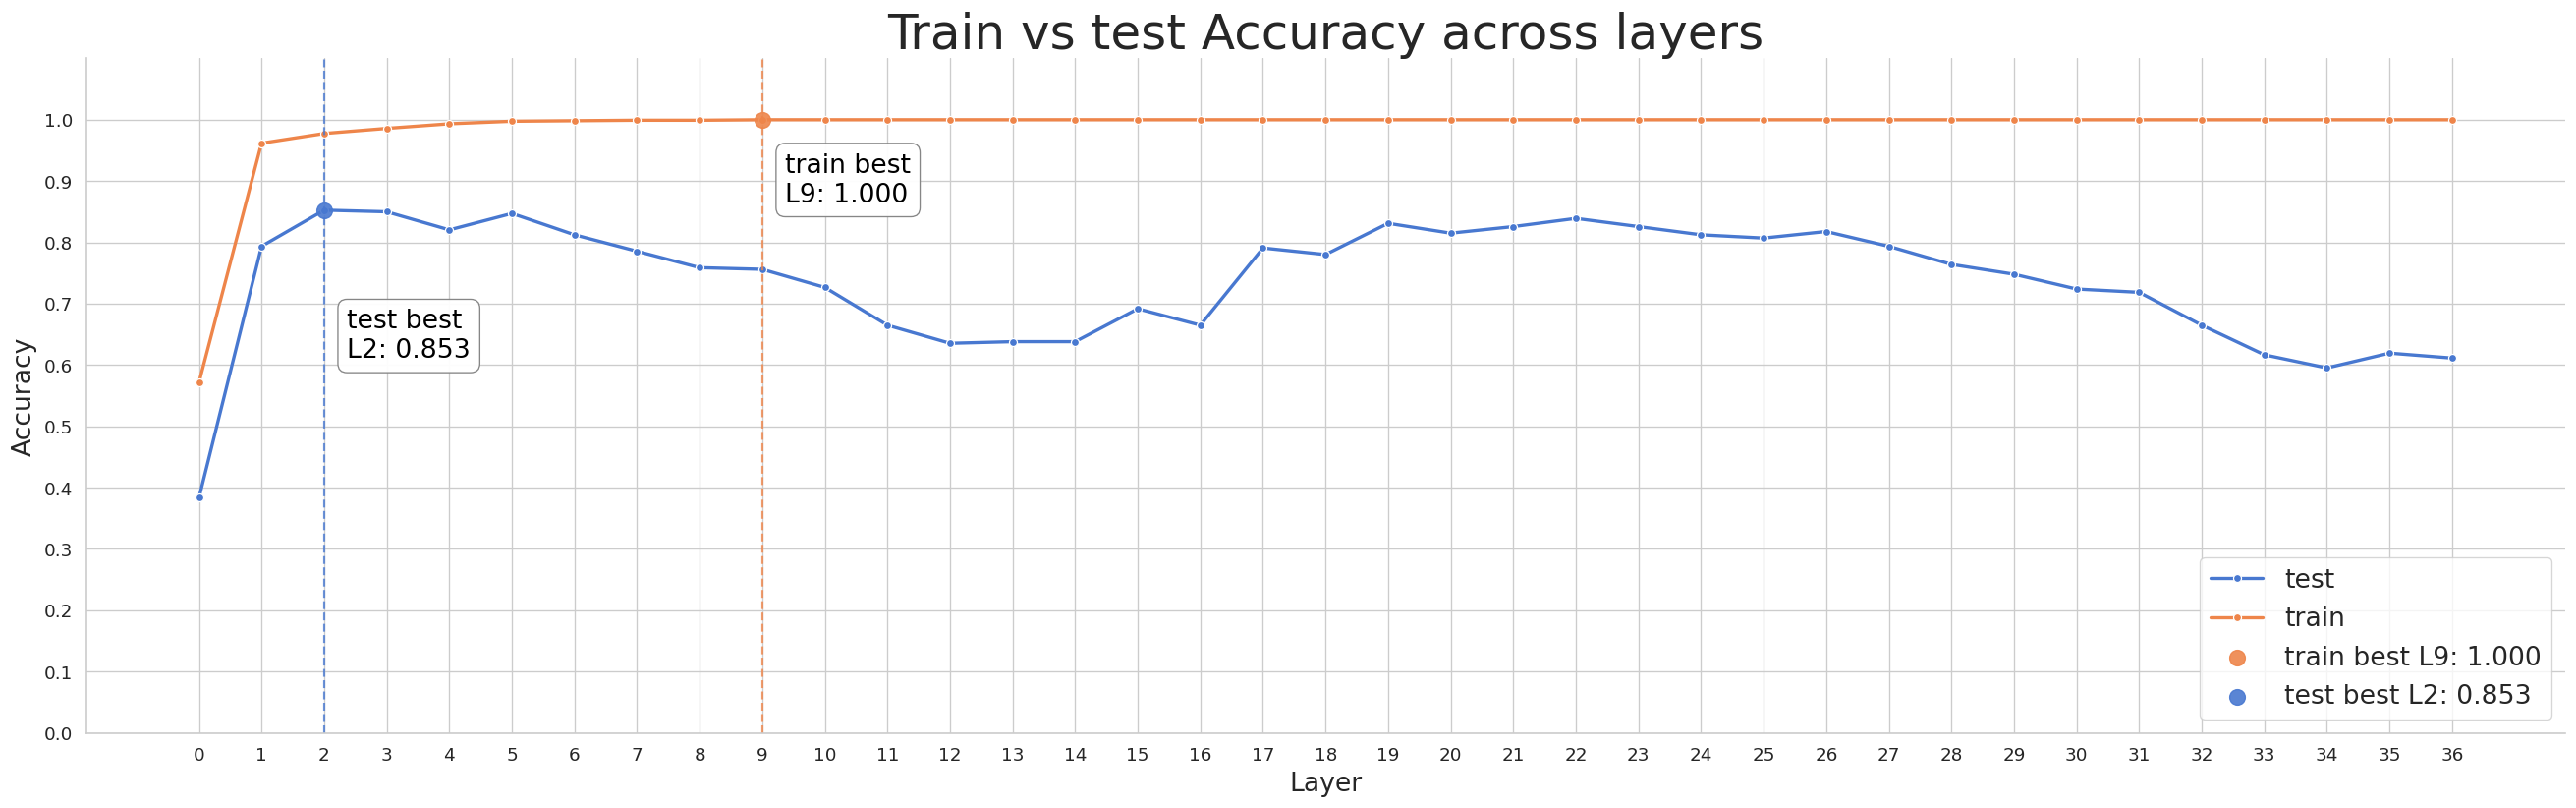

In [ ]:
plot_train_test_metric_with_best(
    metric_col="accuracy",
    save_name="layerwise_train_vs_test_accuracy_with_best",
    annotation_offsets={
        "train": {
            "xytext": (14, -20),
            "ha": "left",
            "va": "top"
        },
        "test": {
            "xytext": (14, -60),
            "ha": "left",
            "va": "top"
        }
    },
    legend_loc="lower right"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_macro_precision_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_macro_precision_with_best.pdf


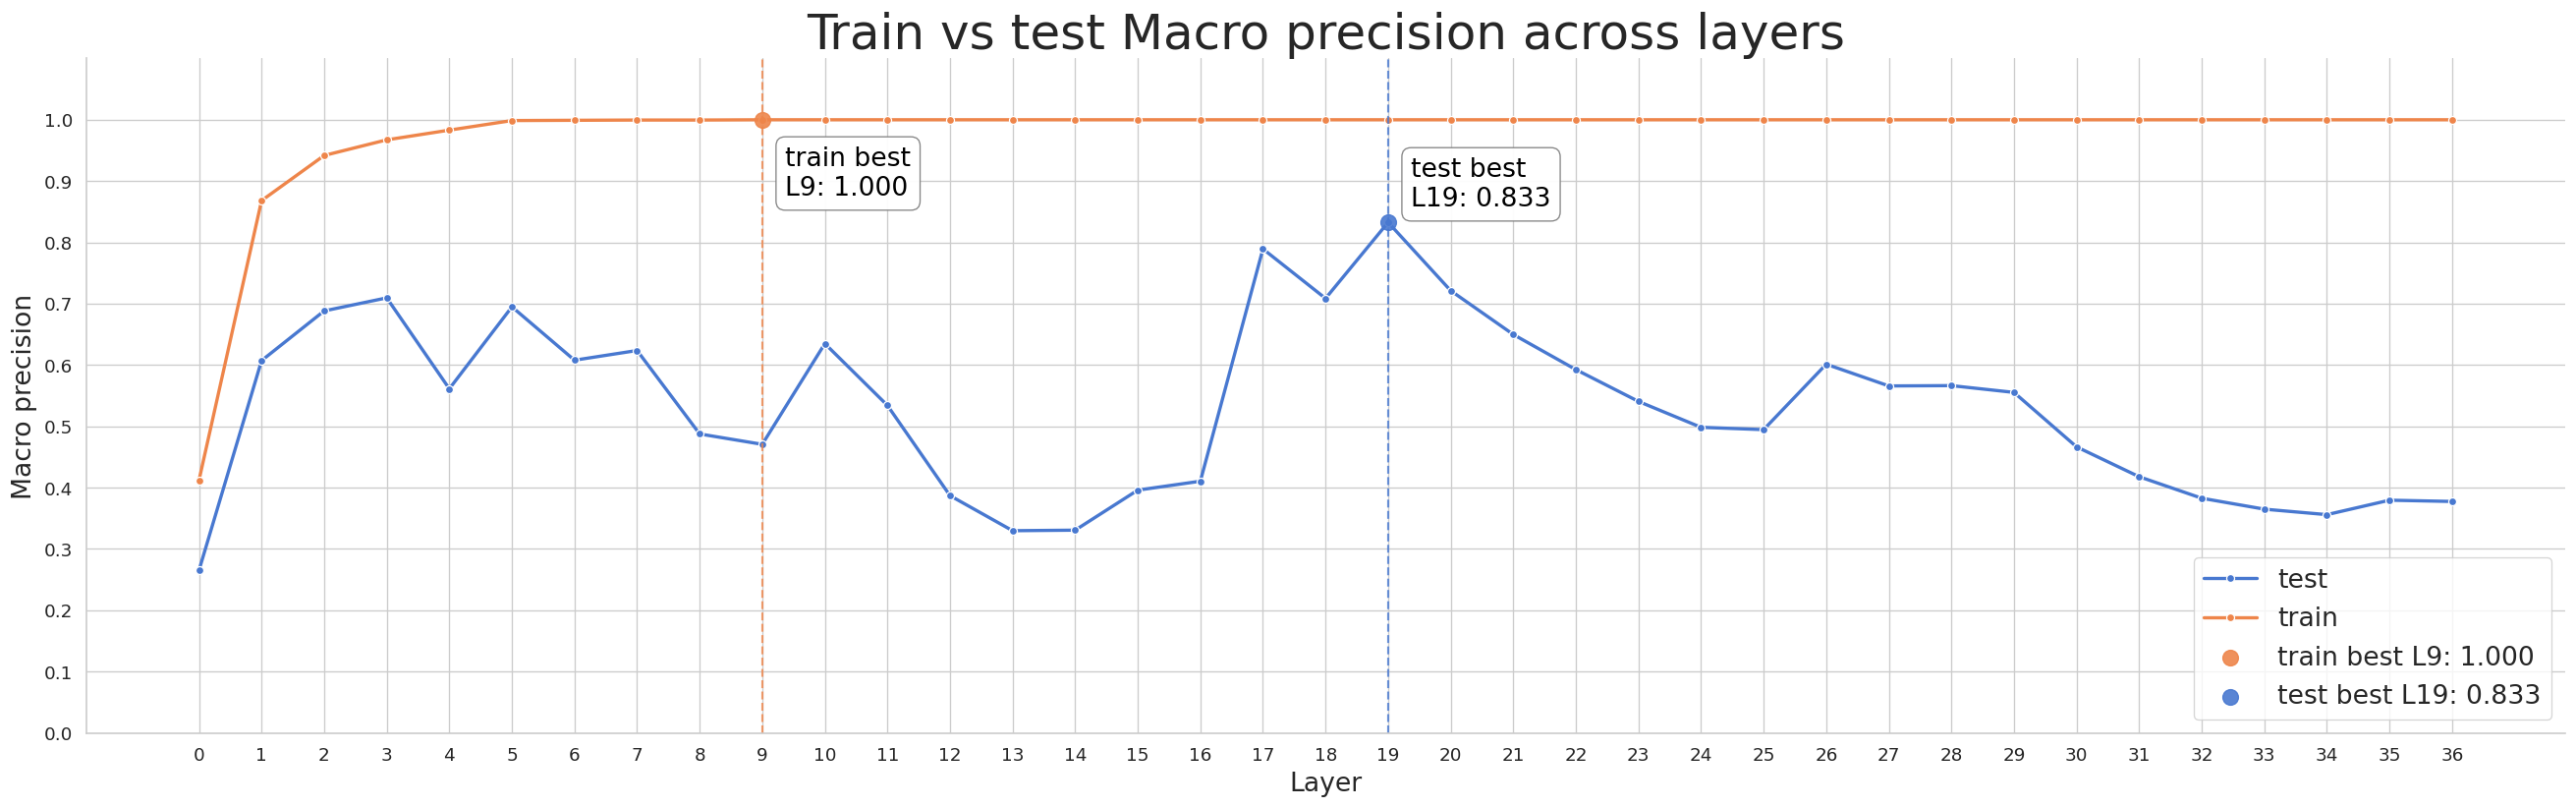

In [ ]:
plot_train_test_metric_with_best(
    metric_col="macro_precision",
    save_name="layerwise_train_vs_test_macro_precision_with_best",
    annotation_offsets={
        "train": {
            "xytext": (14, -16),
            "ha": "left",
            "va": "top"
        },
        "test": {
            "xytext": (14, 40),
            "ha": "left",
            "va": "top"
        }
    },
    legend_loc="lower right"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_macro_recall_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_macro_recall_with_best.pdf


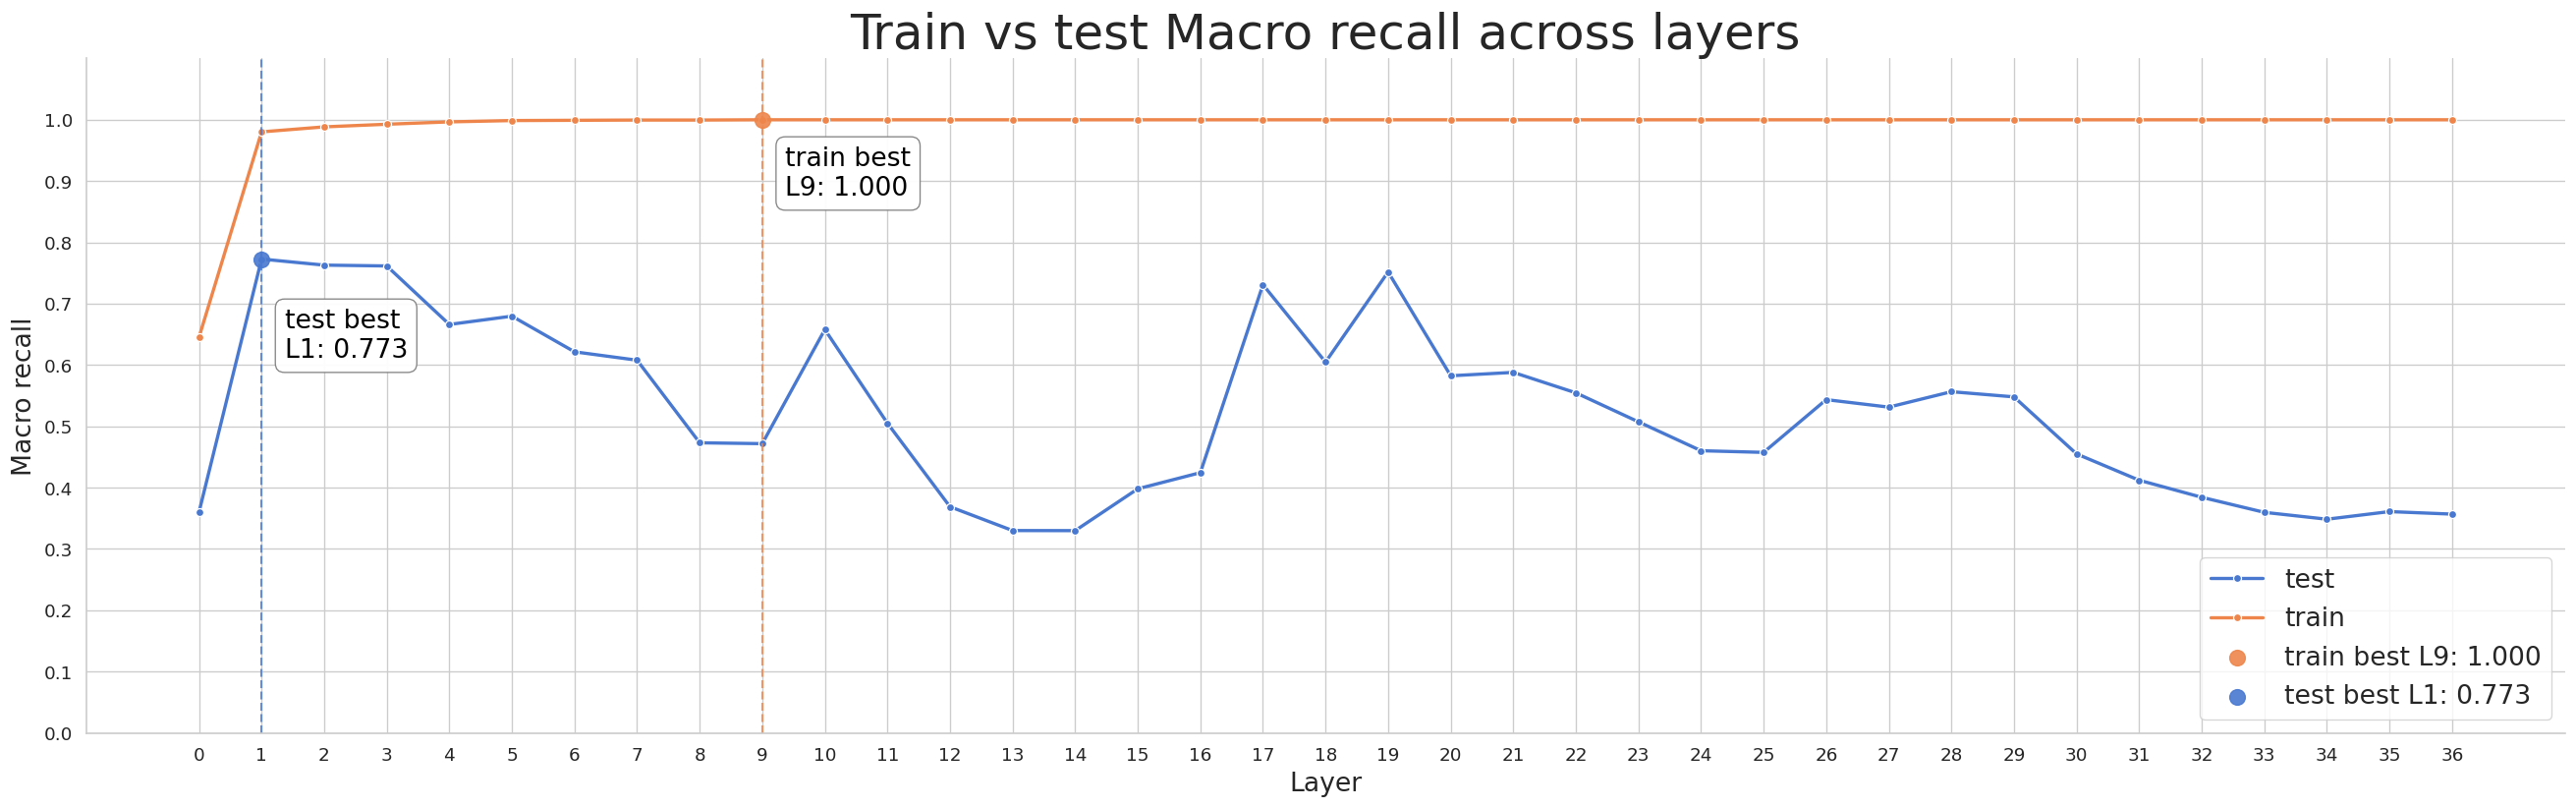

In [ ]:
plot_train_test_metric_with_best(
    metric_col="macro_recall",
    save_name="layerwise_train_vs_test_macro_recall_with_best",
    annotation_offsets={
        "train": {
            "xytext": (14, -16),
            "ha": "left",
            "va": "top"
        },
        "test": {
            "xytext": (14, -30),
            "ha": "left",
            "va": "top"
        }
    },
    legend_loc="lower right"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_macro_f1_with_best.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_macro_f1_with_best.pdf


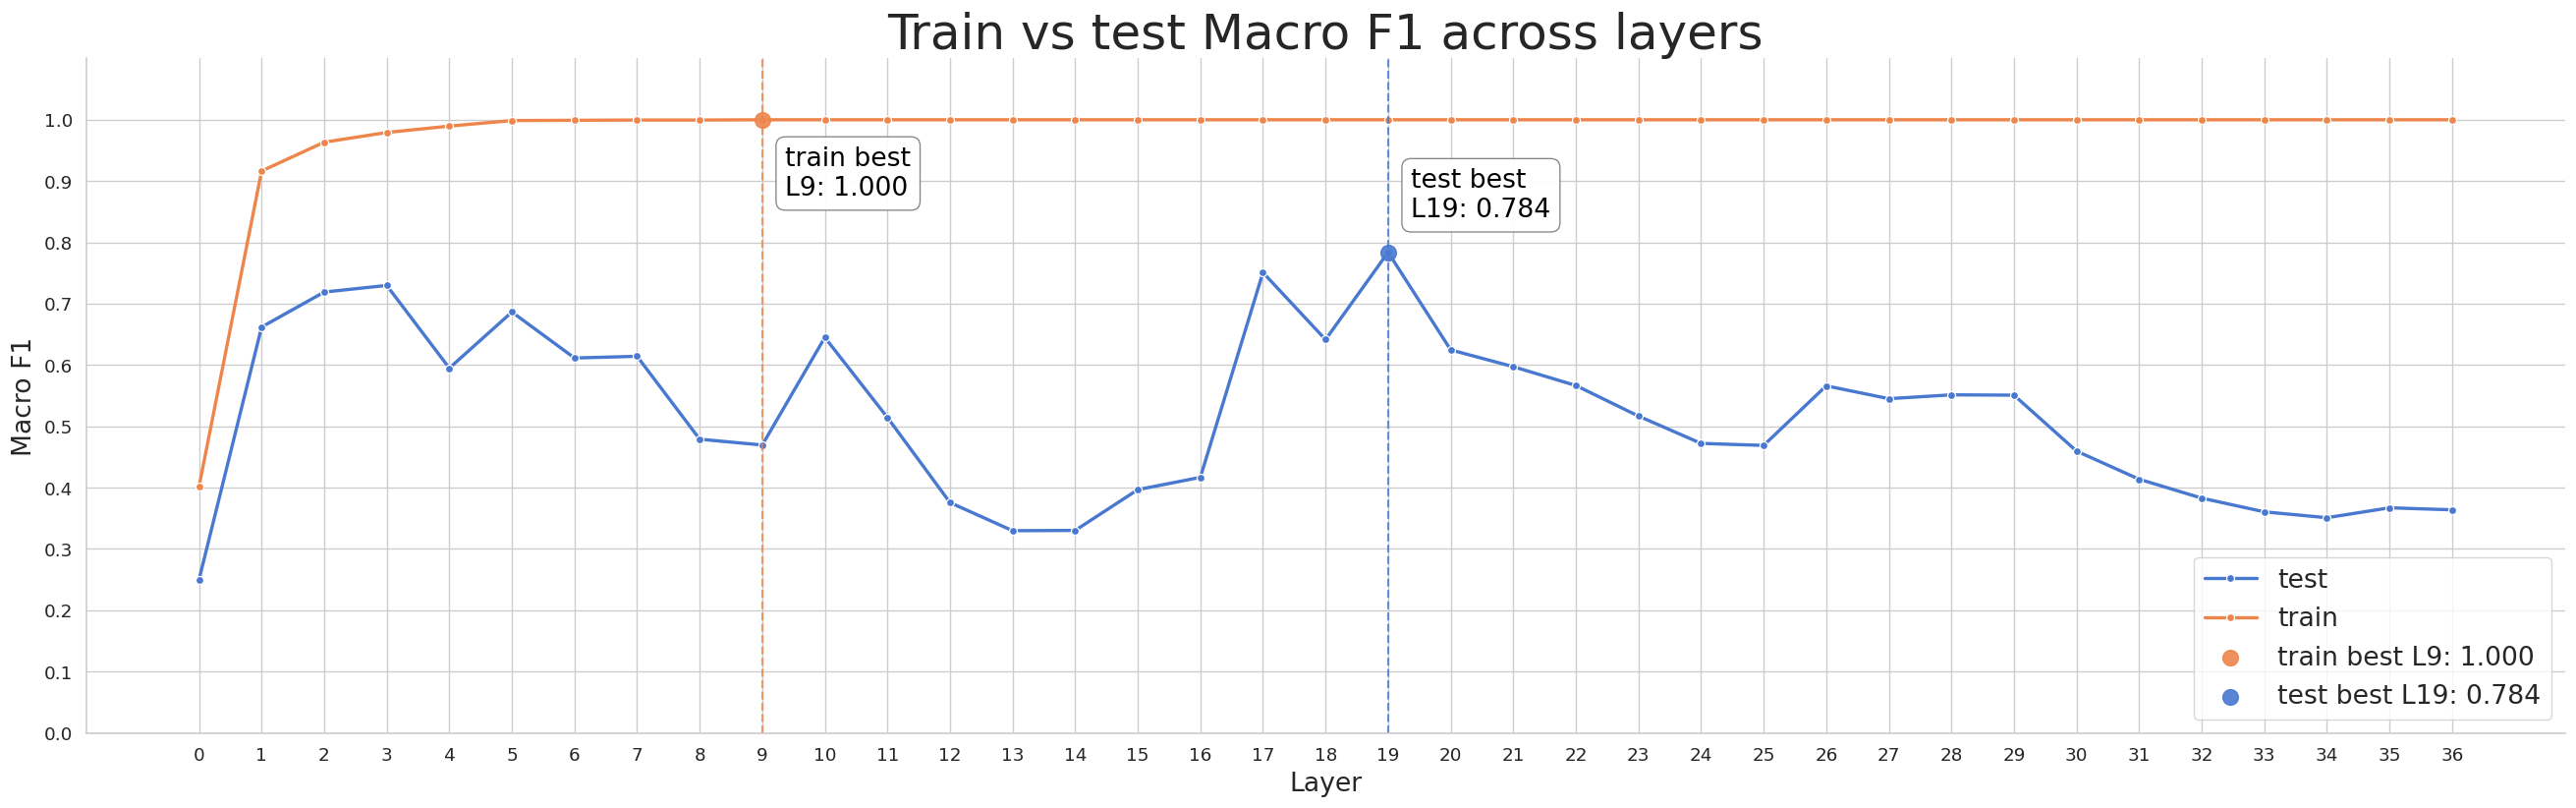

In [ ]:
plot_train_test_metric_with_best(
    metric_col="macro_f1",
    save_name="layerwise_train_vs_test_macro_f1_with_best",
    annotation_offsets={
        "train": {
            "xytext": (14, -16),
            "ha": "left",
            "va": "top"
        },
        "test": {
            "xytext": (14, 18),
            "ha": "left",
            "va": "bottom"
        }
    },
    legend_loc="lower right"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_all_metrics.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/layerwise_train_vs_test_all_metrics.pdf


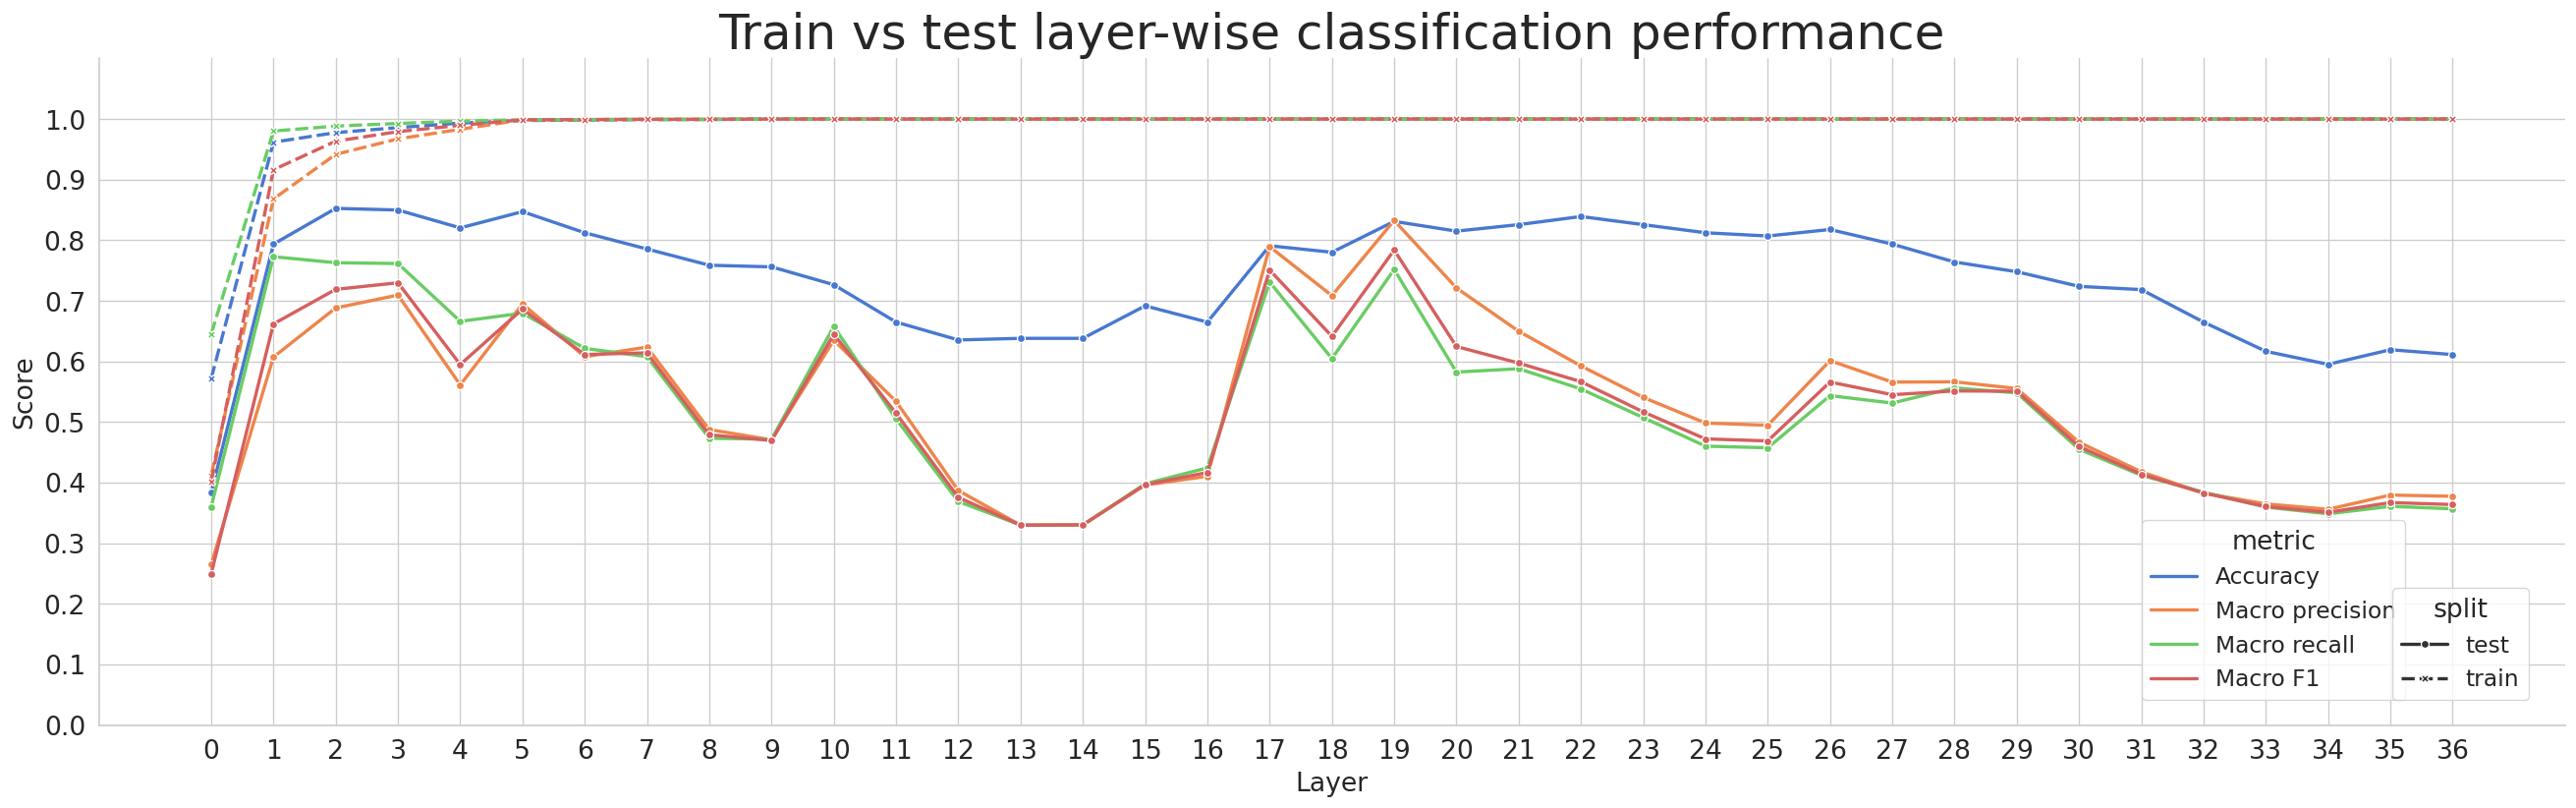

In [ ]:
df_train_test_long = df_train_test.melt(
    id_vars=["layer", "split"],
    value_vars=["accuracy", "macro_precision", "macro_recall", "macro_f1"],
    var_name="metric_col",
    value_name="score"
)

df_train_test_long["metric"] = df_train_test_long["metric_col"].map(METRIC_NAME_MAP)

if df_train_test_long["metric"].isna().any():
    missing_metric_cols = df_train_test_long.loc[
        df_train_test_long["metric"].isna(),
        "metric_col"
    ].unique()

    raise ValueError(
        f"Some metric columns are missing in METRIC_NAME_MAP: {missing_metric_cols}"
    )

plt.figure(figsize=(22, 7))

sns.lineplot(
    data=df_train_test_long,
    x="layer",
    y="score",
    hue="metric",
    style="split",
    markers=True,
    dashes=True,
    linewidth=2.0,
    palette="muted"
)

plt.title(
    "Train vs test layer-wise classification performance",
    fontsize=30
)

plt.xlabel("Layer", fontsize=16)
plt.ylabel("Score", fontsize=16)

plt.ylim(0, 1.10)
plt.yticks(np.arange(0, 1.01, 0.1), fontsize=16)
plt.xticks(sorted(df_train_test_long["layer"].unique()), fontsize=16)

ax = plt.gca()

handles, labels = ax.get_legend_handles_labels()

metric_handles = []
metric_labels = []
split_handles = []
split_labels = []

mode = None

for handle, label in zip(handles, labels):
    if label == "metric":
        mode = "metric"
        continue
    elif label == "split":
        mode = "split"
        continue

    if mode == "metric":
        metric_handles.append(handle)
        metric_labels.append(label)
    elif mode == "split":
        split_handles.append(handle)
        split_labels.append(label)

legend_metric = ax.legend(
    metric_handles,
    metric_labels,
    title="metric",
    frameon=True,
    fontsize=14,
    title_fontsize=16,
    loc="lower right",
    bbox_to_anchor=(0.94, 0.02),
    ncol=1
)

ax.add_artist(legend_metric)

legend_split = ax.legend(
    split_handles,
    split_labels,
    title="split",
    frameon=True,
    fontsize=14,
    title_fontsize=16,
    loc="lower right",
    bbox_to_anchor=(0.99, 0.02),
    ncol=1
)

plt.tight_layout()

save_fig("layerwise_train_vs_test_all_metrics")
plt.show()

In [ ]:
per_label_rows = []

for layer_result in results["results_by_layer"]:
    layer = int(layer_result["layer"])

    if TEST_KEY not in layer_result:
        continue

    report = layer_result[TEST_KEY].get("classification_report", {})

    for label in label_order:
        label_report = report.get(label, {})

        per_label_rows.append({
            "layer": layer,
            "label": label,
            "precision": label_report.get("precision", np.nan),
            "recall": label_report.get("recall", np.nan),
            "f1_score": label_report.get("f1-score", np.nan),
            "support": label_report.get("support", np.nan),
        })

df_label_metrics = pd.DataFrame(per_label_rows)

print(df_label_metrics.head())
print("\nShape:", df_label_metrics.shape)

   layer     label  precision    recall  f1_score  support
0      0     above   0.075472  0.666667  0.135593      6.0
1      0     below   0.000000  0.000000  0.000000      6.0
2      0   left_of   0.484375  0.335135  0.396166    185.0
3      0  right_of   0.500000  0.437500  0.466667    176.0
4      1     above   0.333333  0.666667  0.444444      6.0

Shape: (148, 6)


In [ ]:
LABEL_METRIC_NAME_MAP = {
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1 score",
    "support": "Support",
}


def require_label_metric_column(df, metric_col):
    if metric_col not in df.columns:
        raise ValueError(
            f"Label metric column '{metric_col}' does not exist. "
            f"Available columns: {list(df.columns)}"
        )

    if metric_col not in LABEL_METRIC_NAME_MAP:
        raise ValueError(
            f"Label metric column '{metric_col}' is not registered in LABEL_METRIC_NAME_MAP."
        )

    if not pd.api.types.is_numeric_dtype(df[metric_col]):
        raise TypeError(f"Label metric column '{metric_col}' is not numeric.")

    return LABEL_METRIC_NAME_MAP[metric_col]

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_per_label_precision_recall_f1.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_per_label_precision_recall_f1.pdf


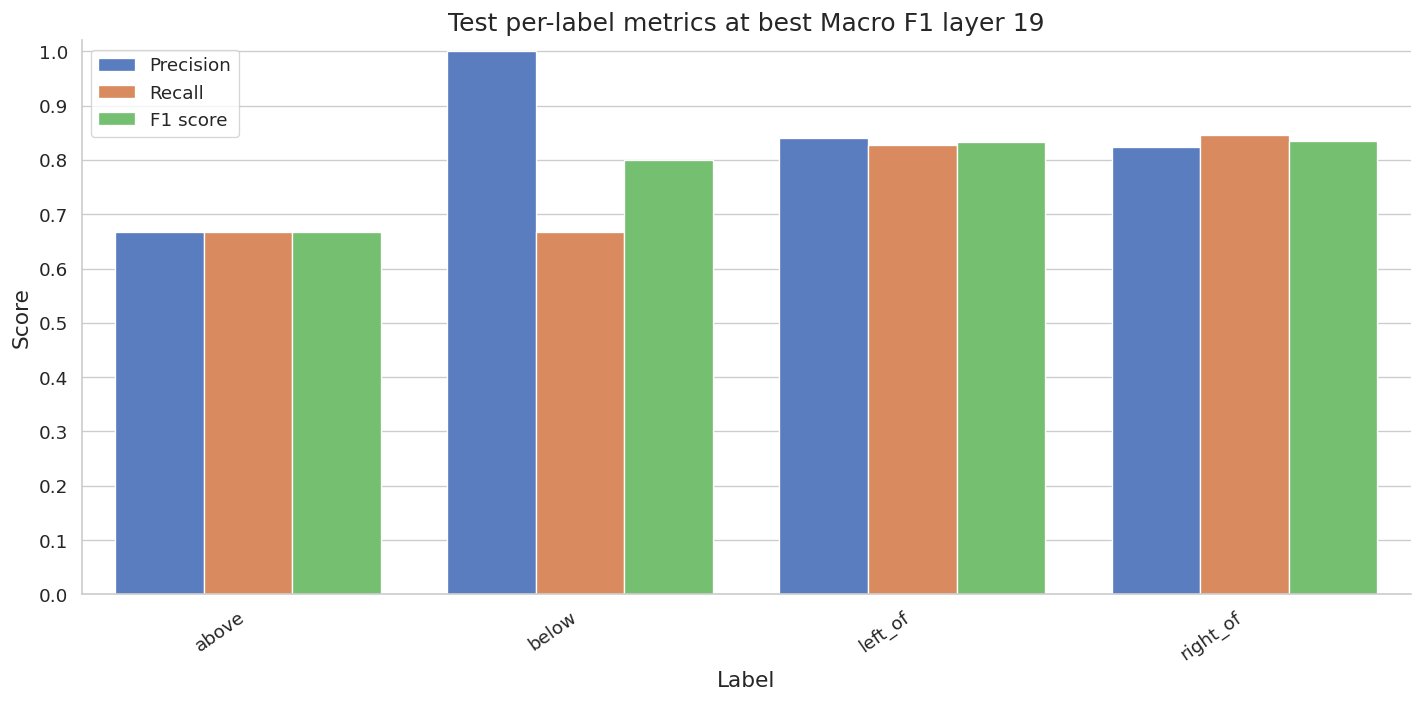

In [ ]:
best_label_df = df_label_metrics[df_label_metrics["layer"] == best_layer].copy()

best_label_long = best_label_df.melt(
    id_vars=["layer", "label", "support"],
    value_vars=["precision", "recall", "f1_score"],
    var_name="metric_col",
    value_name="score"
)

best_label_long["metric"] = best_label_long["metric_col"].map(LABEL_METRIC_NAME_MAP)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_label_long,
    x="label",
    y="score",
    hue="metric",
    palette="muted"
)

plt.title(f"Test per-label metrics at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Label")
plt.ylabel("Score")
plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(rotation=35, ha="right")
plt.legend(title=None, frameon=True)
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_test_per_label_precision_recall_f1")
plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_per_label_recall.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_per_label_recall.pdf


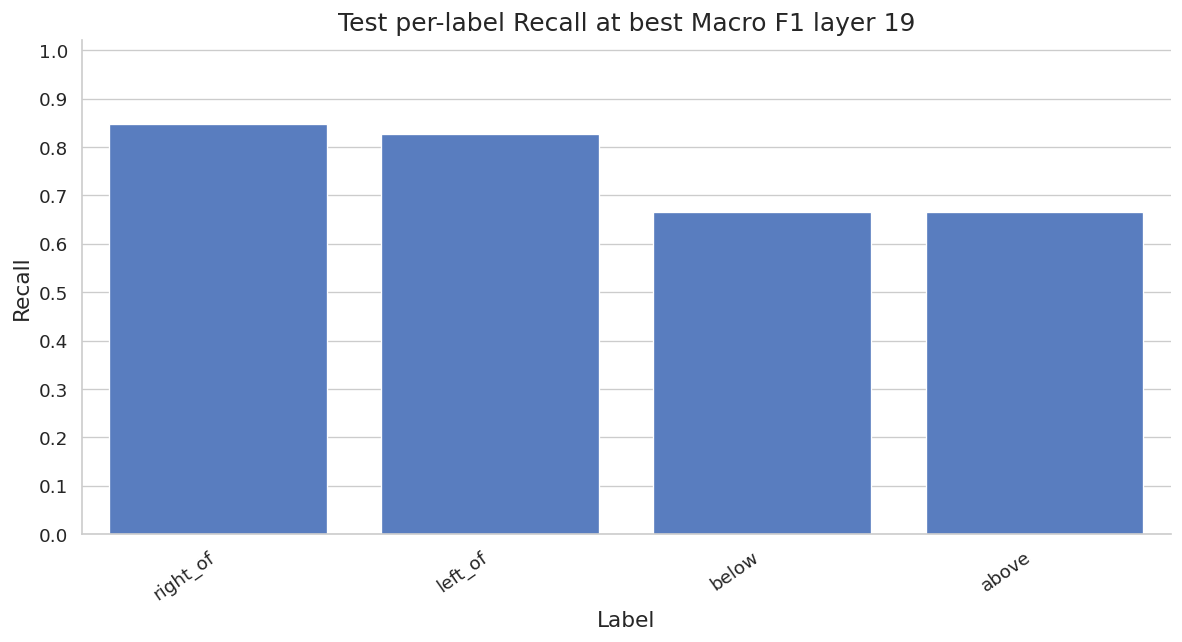

In [ ]:
label_metric_col = "recall"
label_metric_label = require_label_metric_column(df_label_metrics, label_metric_col)

best_label_df = df_label_metrics[df_label_metrics["layer"] == best_layer].copy()

plt.figure(figsize=(10, 5.5))

order_by_metric = best_label_df.sort_values(label_metric_col, ascending=False)["label"]

sns.barplot(
    data=best_label_df,
    x="label",
    y=label_metric_col,
    order=order_by_metric,
    color=sns.color_palette("muted")[0]
)

plt.title(f"Test per-label {label_metric_label} at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Label")
plt.ylabel(label_metric_label)
plt.ylim(0, 1.02)
plt.yticks(np.arange(0, 1.01, 0.1))
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_test_per_label_{label_metric_col}")
plt.show()

In [ ]:
def plot_label_by_layer_heatmap(metric_col, save_name):
    metric_label = require_label_metric_column(df_label_metrics, metric_col)

    metric_matrix = df_label_metrics.pivot(
        index="label",
        columns="layer",
        values=metric_col
    ).loc[label_order]

    plt.figure(figsize=(30, 5))

    sns.heatmap(
        metric_matrix,
        annot=True,
        fmt=".2f",
        cmap="viridis",
        vmin=0,
        vmax=1,
        linewidths=0,
        linecolor=None,
        cbar_kws={"label": metric_label},
        annot_kws={"size": 14}
    )

    plt.title(f"Test {metric_label} heatmap by label and layer")
    plt.xlabel("Layer")
    plt.ylabel("Label")
    plt.tight_layout()

    save_fig(save_name)
    plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_label_by_layer_recall_heatmap.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_label_by_layer_recall_heatmap.pdf


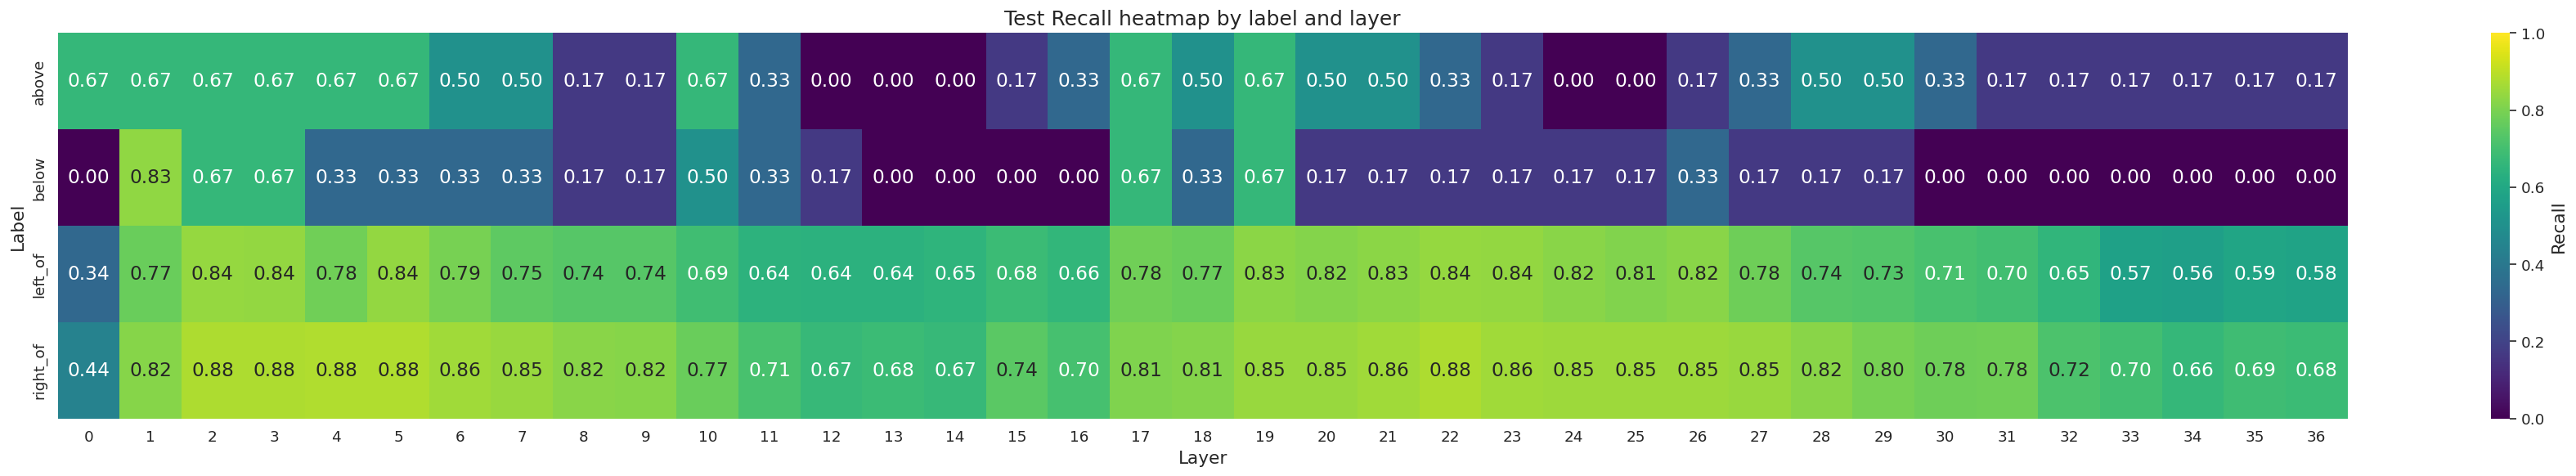

In [ ]:
plot_label_by_layer_heatmap(
    metric_col="recall",
    save_name="test_label_by_layer_recall_heatmap"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_label_by_layer_precision_heatmap.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/test_label_by_layer_precision_heatmap.pdf


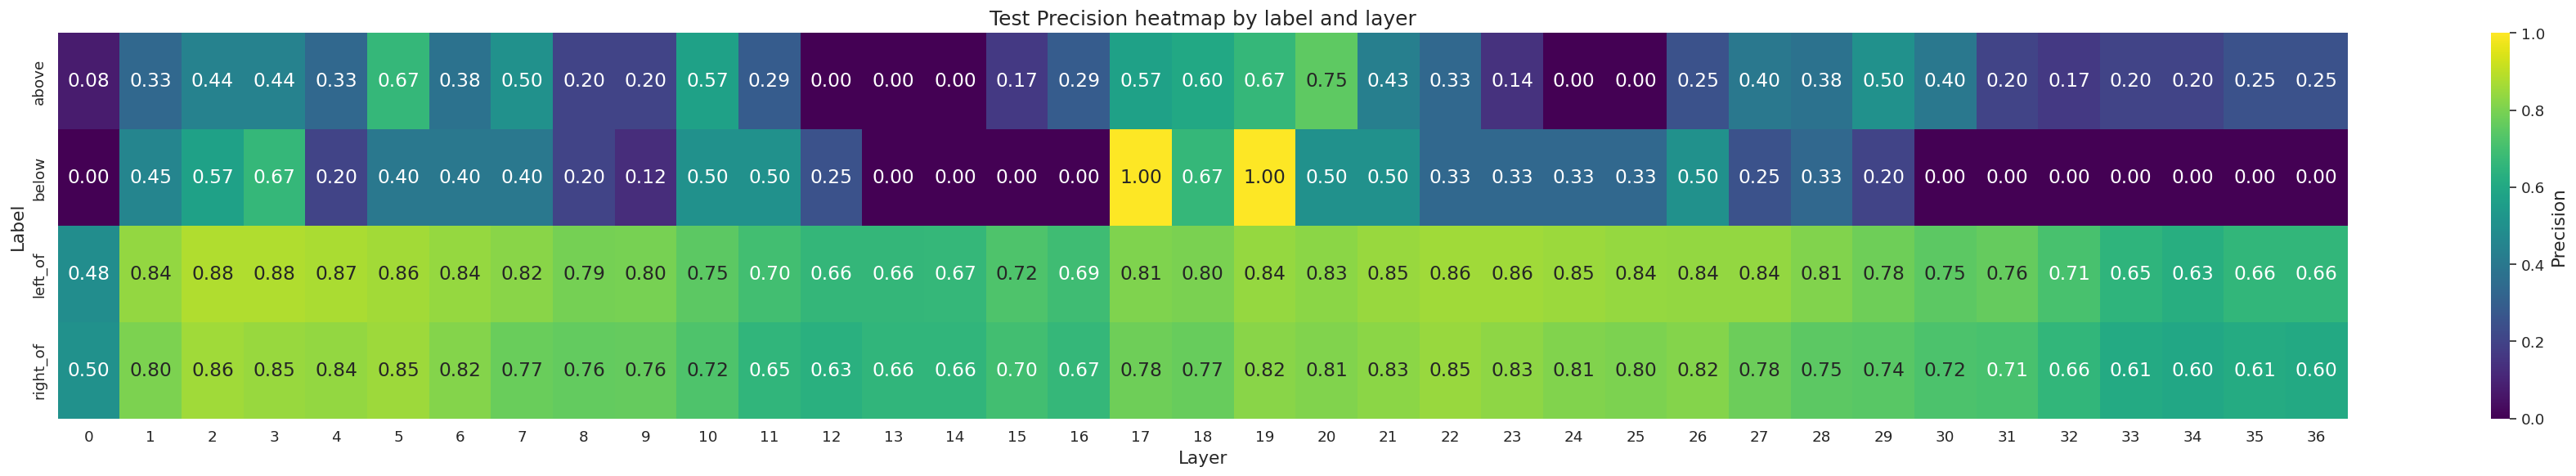

In [ ]:
plot_label_by_layer_heatmap(
    metric_col="precision",
    save_name="test_label_by_layer_precision_heatmap"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/overall_label_by_layer_f1_heatmap.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/overall_label_by_layer_f1_heatmap.pdf


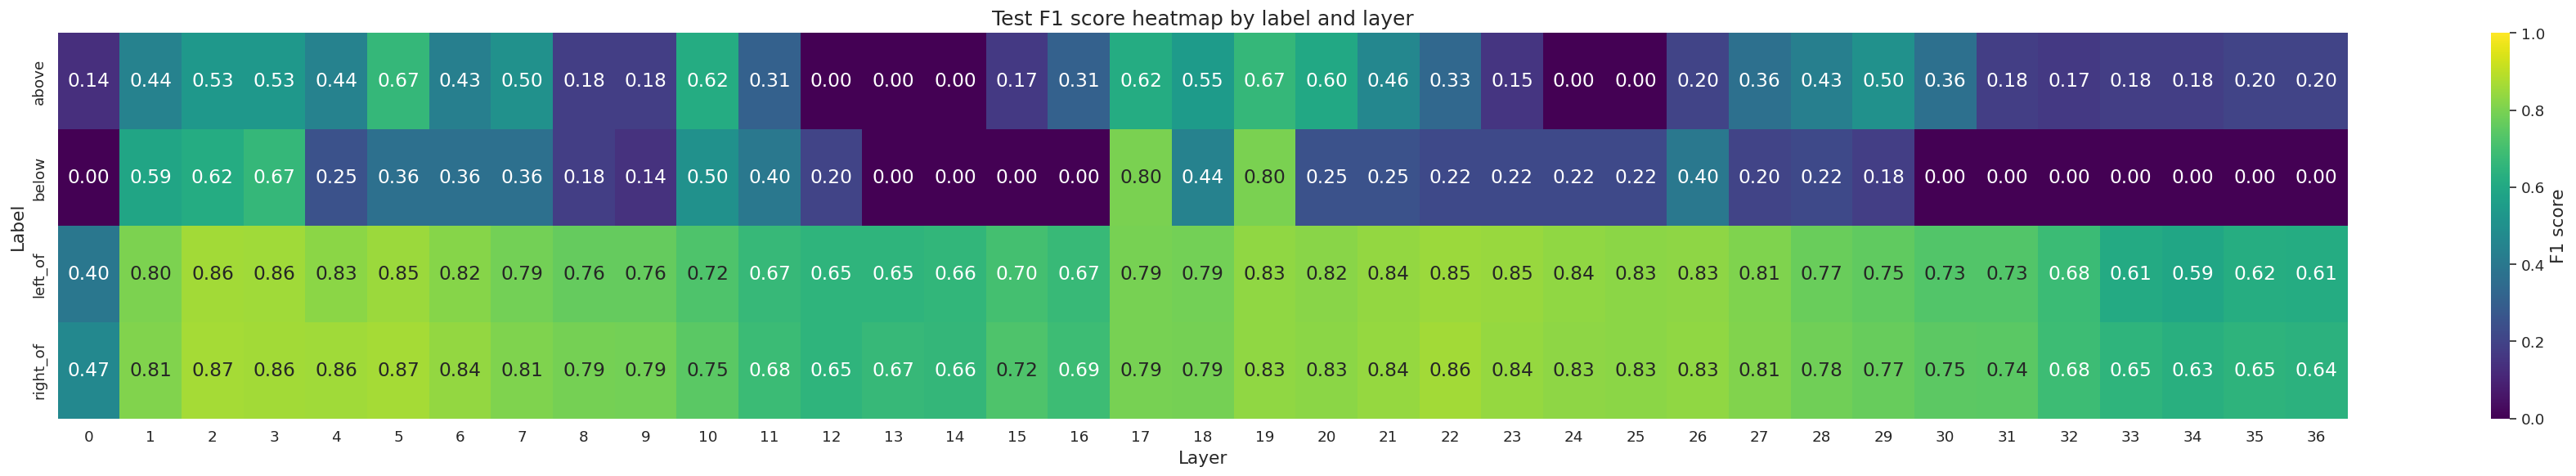

In [ ]:
plot_label_by_layer_heatmap(
    metric_col="f1_score",
    save_name="overall_label_by_layer_f1_heatmap"
)

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_confusion_matrix.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_confusion_matrix.pdf


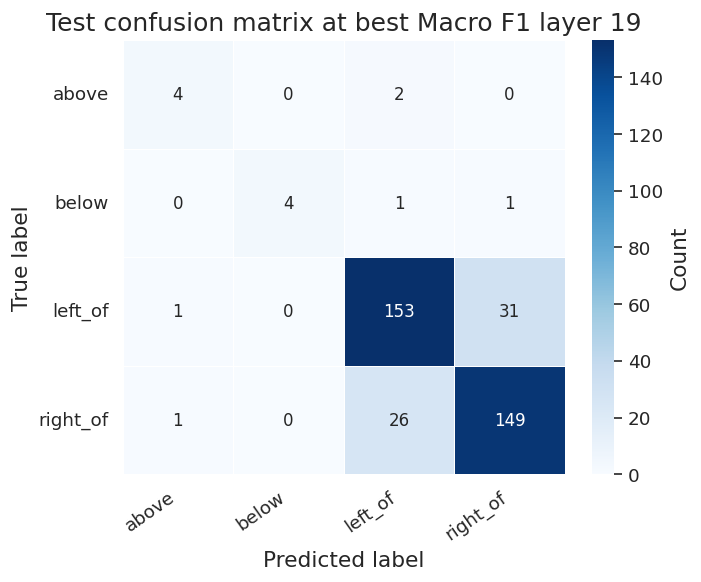

In [ ]:
best_layer_result = None

for layer_result in results["results_by_layer"]:
    if int(layer_result["layer"]) == best_layer:
        best_layer_result = layer_result
        break

assert best_layer_result is not None, f"Best layer {best_layer} not found."

cm = np.asarray(best_layer_result[TEST_KEY]["confusion_matrix"])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
    linewidths=0.4,
    cbar_kws={"label": "Count"},
    annot_kws={"size": 10}
)

plt.title(f"Test confusion matrix at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_test_confusion_matrix")
plt.show()

Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_normalized_confusion_matrix.png
Saved: /content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b/best_macro_f1_layer_19_test_normalized_confusion_matrix.pdf


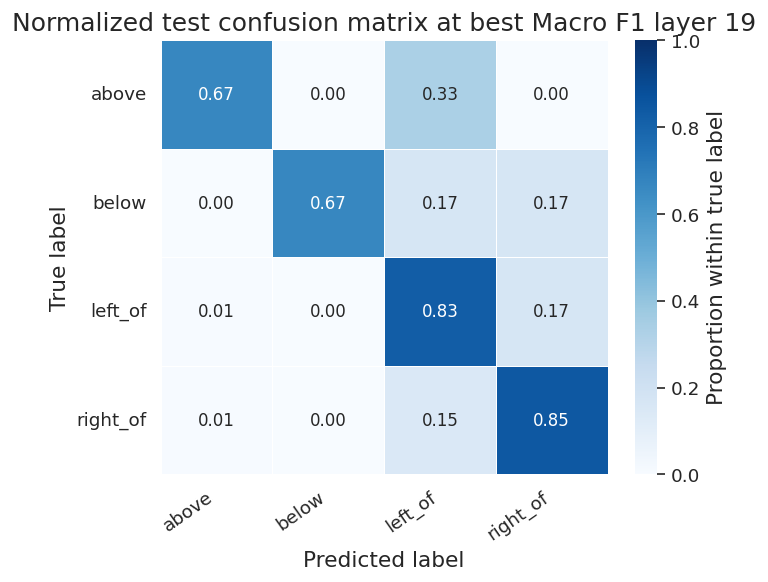

In [ ]:
cm = np.asarray(best_layer_result[TEST_KEY]["confusion_matrix"], dtype=float)

row_sums = cm.sum(axis=1, keepdims=True)

cm_normalized = np.divide(
    cm,
    row_sums,
    out=np.zeros_like(cm, dtype=float),
    where=row_sums != 0
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_order,
    yticklabels=label_order,
    linewidths=0.4,
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Proportion within true label"},
    annot_kws={"size": 10}
)

plt.title(f"Normalized test confusion matrix at best {BEST_LAYER_METRIC_LABEL} layer {best_layer}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

save_fig(f"best_macro_f1_layer_{best_layer}_test_normalized_confusion_matrix")
plt.show()

In [ ]:
# =========================
# Cell 33 — 打包并下载所有 Step7 绘图结果
# =========================

from google.colab import files
import shutil
from pathlib import Path

# 确保 OUT_DIR 是 Path 类型
OUT_DIR = Path(OUT_DIR)

# zip 文件保存位置：放在 OUT_DIR 的上一级目录
ZIP_BASE = OUT_DIR.parent / OUT_DIR.name
ZIP_PATH = Path(str(ZIP_BASE) + ".zip")

# 如果旧 zip 已存在，先删除，避免下载旧结果
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

# 打包整个输出目录
shutil.make_archive(
    base_name=str(ZIP_BASE),
    format="zip",
    root_dir=str(OUT_DIR)
)

print("Created zip file:")
print(ZIP_PATH)
print("Zip file exists:", ZIP_PATH.exists())

# 触发浏览器下载
files.download(str(ZIP_PATH))

Created zip file:
/content/drive/MyDrive/Colab Notebooks/linear_probe_full/data_prepare_step1_3/data/step7_vis/plots_step6_composition_implicit_transitive_qwen2_5_3b.zip
Zip file exists: True


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>